---
format: 
    html:
        embed-resources: true
---


In [ ]:
#import libraries
import pandas as pd
import numpy as np
import seaborn as sns #import seaborn library
import matplotlib.pyplot as plt #import matplotlib.pyplot library

#attempt with the pdfplumber library to extract table from pdf file
#import pdfplumber

In [429]:
#attempt worked correctly with camelot library function
#import camelot library for table extraction from pdf
import camelot

#set pdf file path
pdf_file = "../../data/raw-data/financial-statement-fy2023.pdf"

#extract table from pdf on page 9 using 'stream" because table data has no border
tables = camelot.read_pdf(pdf_file, flavor='stream', pages='9')

#if it is a table and table is found, then convert the table into a dataframe
if tables:
    df = tables[0].df
    print(df)
else:
    print("no tables found")

                                                    0  1            2  \
0                                                                       
1                                                                2023   
2                                  Operating revenue:                   
3                         Revenue from transportation  $      376,357   
4                                               Other          76,616   
5                            Total operating revenues         452,973   
6                                 Operating expenses:                   
7                             Transportation services         822,671   
8                            Other operating expenses         968,312   
9    Total operating expenses, excluding depreciation       1,790,983   
10                      Depreciation and amortization         562,247   
11  Total operating expenses, including depreciati...                   
12                                       amortizati

In [430]:
#drop unneeded columns from the df dataframe. Drop columns with default headers 1 and 3
df.drop([1,3], axis=1, inplace=True)
#print(df) #print dataframe to check columns dropped


In [431]:
#drop unneeded rows with indexes 0,1, and 2
df.drop([0,1,2], inplace=True)
#print(df)

In [432]:
#rename headers in dataframe
df.rename(columns={0:"Statements of Revenue, Expenses and Changes in Net Position", 2:"June 30, 2023", 4:"June 30, 2022"}, inplace=True)
print(df)

   Statements of Revenue, Expenses and Changes in Net Position June 30, 2023  \
3                         Revenue from transportation                376,357   
4                                               Other                 76,616   
5                            Total operating revenues                452,973   
6                                 Operating expenses:                          
7                             Transportation services                822,671   
8                            Other operating expenses                968,312   
9    Total operating expenses, excluding depreciation              1,790,983   
10                      Depreciation and amortization                562,247   
11  Total operating expenses, including depreciati...                          
12                                       amortization              2,353,230   
13                                     Operating loss            (1,900,257)   
14                          Nonoperating

In [433]:
#rename some values in the "Statements of Revenue, Expenses and Changes in Net Position" column because the table was formatted with too much space for those cells
df.at[4,"Statements of Revenue, Expenses and Changes in Net Position"] = "Other revenue"
df.at[12,"Statements of Revenue, Expenses and Changes in Net Position"] = "Total operating expenses, including depreciation and amortization"
#print(df)

In [434]:
#drop rows index 6 and 11 because they had blank values and other rows were correctly renamed
df.drop([6,11], inplace=True)
print(df)

   Statements of Revenue, Expenses and Changes in Net Position June 30, 2023  \
3                         Revenue from transportation                376,357   
4                                       Other revenue                 76,616   
5                            Total operating revenues                452,973   
7                             Transportation services                822,671   
8                            Other operating expenses                968,312   
9    Total operating expenses, excluding depreciation              1,790,983   
10                      Depreciation and amortization                562,247   
12  Total operating expenses, including depreciati...              2,353,230   
13                                     Operating loss            (1,900,257)   
14                          Nonoperating revenue, net              1,812,580   
15  Gain/(Loss) before capital grants and contribu...               (87,677)   
16                   Capital grants and 

In [435]:
#check the data types of columns in the dataframe
print(df.dtypes)
df["Statements of Revenue, Expenses and Changes in Net Position"] = df["Statements of Revenue, Expenses and Changes in Net Position"].astype(str) #transform data type from objects into strings in this column

df["June 30, 2023"] = df["June 30, 2023"].str.replace(",", "") #remove comma characters in column "June 30, 2023"
df["June 30, 2022"] = df["June 30, 2022"].str.replace(",", "") #remove comma characters in column "June 30, 2022"

df["June 30, 2023"] = df["June 30, 2023"].str.replace("(", "") #remove '(' characters in column "June 30, 2023"
df["June 30, 2023"] = df["June 30, 2023"].str.replace(")", "") #remove ')' characters in column "June 30, 2023"

df["June 30, 2022"] = df["June 30, 2022"].str.replace("(", "") #remove '(' characters in column "June 30, 2022"
df["June 30, 2022"] = df["June 30, 2022"].str.replace(")", "") #remove ')' characters in column "June 30, 2022"


df["June 30, 2023"] = df["June 30, 2023"].astype(int) #convert "June 30, 2023" column data type to numeric
df["June 30, 2022"] = df["June 30, 2022"].astype(int) #convert "June 30, 2022" column data type to numeric

print("After conversion", df.dtypes)
print(df)

Statements of Revenue, Expenses and Changes in Net Position    object
June 30, 2023                                                  object
June 30, 2022                                                  object
dtype: object
After conversion Statements of Revenue, Expenses and Changes in Net Position    object
June 30, 2023                                                   int64
June 30, 2022                                                   int64
dtype: object
   Statements of Revenue, Expenses and Changes in Net Position  June 30, 2023  \
3                         Revenue from transportation                  376357   
4                                       Other revenue                   76616   
5                            Total operating revenues                  452973   
7                             Transportation services                  822671   
8                            Other operating expenses                  968312   
9    Total operating expenses, excluding deprecia

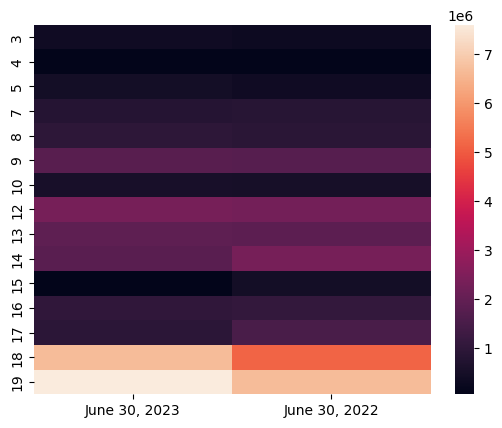

In [436]:
#subset dataframe to create a heatmap to visualize missing data even though there were no missing data. Keep numeric value columns
df_subset = df[["June 30, 2023", "June 30, 2022"]]

#create heatmap of dataframe
sns.heatmap(df_subset)
plt.show() #show heatmap

       June 30, 2023  June 30, 2022
count   1.500000e+01   1.500000e+01
mean    1.827888e+06   1.746877e+06
std     2.270066e+06   1.860407e+06
min     7.661600e+04   6.456500e+04
25%     5.076100e+05   4.891660e+05
50%     9.683120e+05   1.084334e+06
75%     1.856418e+06   2.081990e+06
max     7.603147e+06   6.682694e+06


<Axes: >

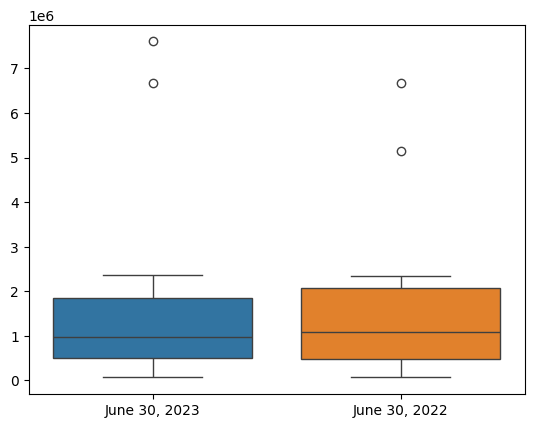

In [437]:
#find outliers in dataframe using describe()
print(df.describe())

#create boxplot of dataframe without na to visualize outliers
sns.boxplot(data=df)

In [438]:
#export budget 2023 net positions data csv file to processed-data folder
df.to_csv("../../data/processed-data/Budget2023_net_positions.csv")

In [118]:
#revenue_pdf_file = "../../data/raw-data/financial-statement-fy2023.pdf"

#extract revenue table from page 10 of the pdf file
revenue_table23 = camelot.read_pdf(pdf_file, flavor='stream', pages='10')

#if it is a table, then extract the second table from page 10
if revenue_table23:
    revenue23_df = revenue_table23[1].df
    print(revenue23_df)
else:
    print("no tables found")

                 0  1        2         3        4         5
0            2022:                                         
1                                Percent            Percent
2                         2023  of total     2022  of total
3              Bus  $   76,549    17 % $   62,305      16 %
4           Subway     176,521      39 %  172,174      45 %
5    Commuter rail     112,801      25 %   80,784      21 %
6  Other passenger      10,486       2 %    7,029       2 %
7  Other operating      76,616      17 %   64,565      16 %
8                   $  452,973   100 % $  386,857     100 %


In [119]:
#drop unneeded columns from the df dataframe. Drop columns with default header 1
revenue23_df.drop(1, axis=1, inplace=True)
#print(revenue23_df) #print dataframe to check columns dropped


                 0        2         3        4         5
0            2022:                                      
1                             Percent            Percent
2                      2023  of total     2022  of total
3              Bus   76,549    17 % $   62,305      16 %
4           Subway  176,521      39 %  172,174      45 %
5    Commuter rail  112,801      25 %   80,784      21 %
6  Other passenger   10,486       2 %    7,029       2 %
7  Other operating   76,616      17 %   64,565      16 %
8                   452,973   100 % $  386,857     100 %


In [120]:
#rename column headers in dataframe
revenue23_df.rename(columns={0:"Sources of Operating Revenue", 2:"June 30, 2023 Revenue", 3:"2023 Percent of Total Operating Revenue", 4:"June 30, 2022 Revenue", 5:"2022 Percent of Total Operating Revenue"}, inplace=True)
#print(revenue23_df)


  Sources of Operating Revenue June 30, 2023 Revenue  \
0                        2022:                         
1                                                      
2                                               2023   
3                          Bus                76,549   
4                       Subway               176,521   
5                Commuter rail               112,801   
6              Other passenger                10,486   
7              Other operating                76,616   
8                                            452,973   

  2023 Percent of Total Operating Revenue June 30, 2022 Revenue  \
0                                                                 
1                                 Percent                         
2                                of total                  2022   
3                                  17 % $                62,305   
4                                    39 %               172,174   
5                                    

In [121]:
#drop rows index 6 and 11 because they had blank values and other rows were correctly renamed
revenue23_df.drop([0,1,2], inplace=True)
print(revenue23_df)

  Sources of Operating Revenue June 30, 2023 Revenue  \
3                          Bus                76,549   
4                       Subway               176,521   
5                Commuter rail               112,801   
6              Other passenger                10,486   
7              Other operating                76,616   
8                                            452,973   

  2023 Percent of Total Operating Revenue June 30, 2022 Revenue  \
3                                  17 % $                62,305   
4                                    39 %               172,174   
5                                    25 %                80,784   
6                                     2 %                 7,029   
7                                    17 %                64,565   
8                                 100 % $               386,857   

  2022 Percent of Total Operating Revenue  
3                                    16 %  
4                                    45 %  
5    

In [122]:
#rename some values in the "Sources of Operating Revenue" column because the table was formatted with too much space for those cells
revenue23_df.at[8,"Sources of Operating Revenue"] = "Total Operating Revenue"
print(revenue23_df)


  Sources of Operating Revenue June 30, 2023 Revenue  \
3                          Bus                76,549   
4                       Subway               176,521   
5                Commuter rail               112,801   
6              Other passenger                10,486   
7              Other operating                76,616   
8      Total Operating Revenue               452,973   

  2023 Percent of Total Operating Revenue June 30, 2022 Revenue  \
3                                  17 % $                62,305   
4                                    39 %               172,174   
5                                    25 %                80,784   
6                                     2 %                 7,029   
7                                    17 %                64,565   
8                                 100 % $               386,857   

  2022 Percent of Total Operating Revenue  
3                                    16 %  
4                                    45 %  
5    

In [128]:
#strip white spaces, $ and % characters from values in the dataframe
revenue23_df["2023 Percent of Total Operating Revenue"] = revenue23_df["2023 Percent of Total Operating Revenue"].str.strip().str.replace("$", "").str.replace("%", "")
revenue23_df["2022 Percent of Total Operating Revenue"] = revenue23_df["2022 Percent of Total Operating Revenue"].str.strip().str.replace("$", "").str.replace("%", "")

revenue23_df["June 30, 2023 Revenue"] = revenue23_df["June 30, 2023 Revenue"].str.strip().str.replace(",", "")
revenue23_df["June 30, 2022 Revenue"] = revenue23_df["June 30, 2022 Revenue"].str.strip().str.replace(",", "")

print(revenue23_df)

  Sources of Operating Revenue June 30, 2023 Revenue  \
3                          Bus                 76549   
4                       Subway                176521   
5                Commuter rail                112801   
6              Other passenger                 10486   
7              Other operating                 76616   
8      Total Operating Revenue                452973   

  2023 Percent of Total Operating Revenue June 30, 2022 Revenue  \
3                                      17                 62305   
4                                      39                172174   
5                                      25                 80784   
6                                       2                  7029   
7                                      17                 64565   
8                                     100                386857   

  2022 Percent of Total Operating Revenue  
3                                      16  
4                                      45  
5    

In [130]:
print(revenue23_df.dtypes) #print the data types of columns in dataframe

revenue23_df["Sources of Operating Revenue"] = revenue23_df["Sources of Operating Revenue"].astype(str)
revenue23_df["June 30, 2023 Revenue"] = revenue23_df["June 30, 2023 Revenue"].astype(int)
revenue23_df["2023 Percent of Total Operating Revenue"] = revenue23_df["2023 Percent of Total Operating Revenue"].astype(int)
revenue23_df["June 30, 2022 Revenue"] = revenue23_df["June 30, 2022 Revenue"].astype(int)
revenue23_df["2022 Percent of Total Operating Revenue"] = revenue23_df["2022 Percent of Total Operating Revenue"].astype(int)

print("After data type conversion", revenue23_df.dtypes)


Sources of Operating Revenue               object
June 30, 2023 Revenue                      object
2023 Percent of Total Operating Revenue    object
June 30, 2022 Revenue                      object
2022 Percent of Total Operating Revenue    object
dtype: object
After data type conversion Sources of Operating Revenue               object
June 30, 2023 Revenue                       int64
2023 Percent of Total Operating Revenue     int64
June 30, 2022 Revenue                       int64
2022 Percent of Total Operating Revenue     int64
dtype: object


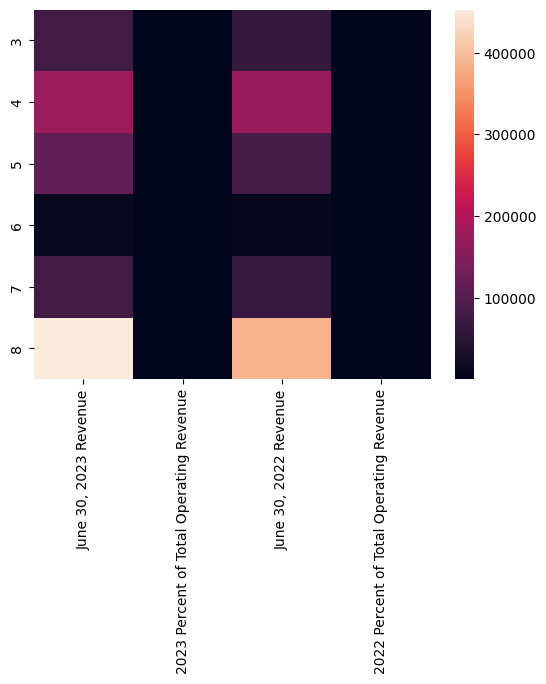

In [131]:
#subset dataframe to create a heatmap to visualize missing data even though there were no missing data. Keep numeric value columns
revenue23_df_subset = revenue23_df[[ "June 30, 2023 Revenue", "2023 Percent of Total Operating Revenue", "June 30, 2022 Revenue", "2022 Percent of Total Operating Revenue"]]

#create heatmap of dataframe
sns.heatmap(revenue23_df_subset)
plt.show() #show heatmap

       June 30, 2023 Revenue  2023 Percent of Total Operating Revenue  \
count               6.000000                                 6.000000   
mean           150991.000000                                33.333333   
std            157555.255284                                34.817620   
min             10486.000000                                 2.000000   
25%             76565.750000                                17.000000   
50%             94708.500000                                21.000000   
75%            160591.000000                                35.500000   
max            452973.000000                               100.000000   

       June 30, 2022 Revenue  2022 Percent of Total Operating Revenue  
count               6.000000                                 6.000000  
mean           128952.333333                                33.333333  
std            137226.828892                                35.539649  
min              7029.000000                          

<Axes: >

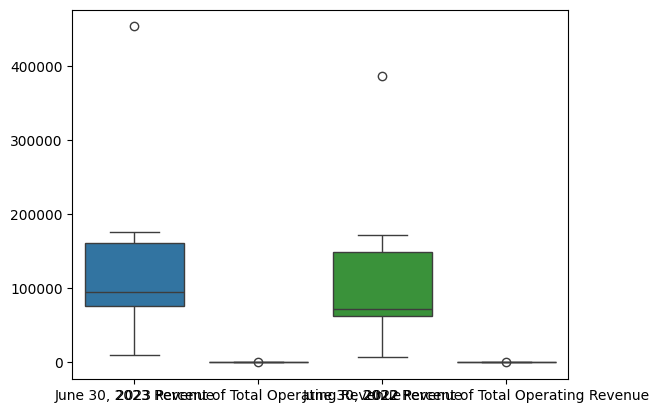

In [132]:
#find outliers in dataframe using describe()
print(revenue23_df.describe())

#create boxplot of dataframe without na to visualize outliers
sns.boxplot(data=revenue23_df)

In [133]:
#export cleaned 2023 operating revenue dataframe in csv file
revenue23_df.to_csv("../../data/processed-data/Budget2023_operating_revenue.csv")

In [134]:
#extract expenses table from pdf on page 11 using 'stream" because table data has no border
expenses_table = camelot.read_pdf(pdf_file, flavor='stream', pages='11')

#if it is a table and table is found, then extract table and convert the table into a dataframe
if expenses_table :
    expenses23_df = expenses_table[0].df
    print(expenses23_df)
else:
    print("no tables found")

                               0  1          2         3          4         5
0                      and 2022:                                             
1                                                Percent              Percent
2                                         2023  of total       2022  of total
3             Wages and benefits  $    822,671    35 % $    858,544      38 %
4                  Commuter rail       634,244      27 %    581,500      26 %
5  Depreciation and amortization       562,247      24 %    526,776      23 %
6          Material and supplies       304,646      13 %    283,548      12 %
7                Other operating        29,422       1 %     25,051       1 %
8                                 $  2,353,230   100 % $  2,275,419     100 %


In [136]:
#drop unneeded columns from the dataframe. Drop columns with default header 1
expenses23_df.drop(1, axis=1, inplace=True)
#print(expenses23_df) #print dataframe to check columns dropped


                               0          2         3          4         5
0                      and 2022:                                          
1                                             Percent              Percent
2                                      2023  of total       2022  of total
3             Wages and benefits    822,671    35 % $    858,544      38 %
4                  Commuter rail    634,244      27 %    581,500      26 %
5  Depreciation and amortization    562,247      24 %    526,776      23 %
6          Material and supplies    304,646      13 %    283,548      12 %
7                Other operating     29,422       1 %     25,051       1 %
8                                 2,353,230   100 % $  2,275,419     100 %


In [137]:
#rename column headers in dataframe
expenses23_df.rename(columns={0:"Sources of Operating Expenses", 2:"June 30, 2023 Expenses", 3:"2023 Percent of Total Operating Expenses", 4:"June 30, 2022 Expenses", 5:"2022 Percent of Total Operating Expenses"}, inplace=True)
#print(expenses23_df)

   Sources of Operating Expenses June 30, 2023 Expenses  \
0                      and 2022:                          
1                                                         
2                                                  2023   
3             Wages and benefits                822,671   
4                  Commuter rail                634,244   
5  Depreciation and amortization                562,247   
6          Material and supplies                304,646   
7                Other operating                 29,422   
8                                             2,353,230   

  2023 Percent of Total Operating Expenses June 30, 2022 Expenses  \
0                                                                   
1                                  Percent                          
2                                 of total                   2022   
3                                   35 % $                858,544   
4                                     27 %                581,50

In [138]:
#drop rows indexes 0,1,2 because they had blank values and other rows were correctly renamed
expenses23_df.drop([0,1,2], inplace=True)
#print(expenses23_df)

   Sources of Operating Expenses June 30, 2023 Expenses  \
3             Wages and benefits                822,671   
4                  Commuter rail                634,244   
5  Depreciation and amortization                562,247   
6          Material and supplies                304,646   
7                Other operating                 29,422   
8                                             2,353,230   

  2023 Percent of Total Operating Expenses June 30, 2022 Expenses  \
3                                   35 % $                858,544   
4                                     27 %                581,500   
5                                     24 %                526,776   
6                                     13 %                283,548   
7                                      1 %                 25,051   
8                                  100 % $              2,275,419   

  2022 Percent of Total Operating Expenses  
3                                     38 %  
4           

In [139]:
#rename total value column "Sources of Operating Expenses" because the table was missing a label for the total operating expenses at bottom of dataframe
expenses23_df.at[8,"Sources of Operating Expenses"] = "Total Operating Expenses"
#print(expenses23_df)

   Sources of Operating Expenses June 30, 2023 Expenses  \
3             Wages and benefits                822,671   
4                  Commuter rail                634,244   
5  Depreciation and amortization                562,247   
6          Material and supplies                304,646   
7                Other operating                 29,422   
8       Total Operating Expenses              2,353,230   

  2023 Percent of Total Operating Expenses June 30, 2022 Expenses  \
3                                   35 % $                858,544   
4                                     27 %                581,500   
5                                     24 %                526,776   
6                                     13 %                283,548   
7                                      1 %                 25,051   
8                                  100 % $              2,275,419   

  2022 Percent of Total Operating Expenses  
3                                     38 %  
4           

In [141]:
#strip white spaces, $ and % characters from values in the dataframe
expenses23_df["2023 Percent of Total Operating Expenses"] = expenses23_df["2023 Percent of Total Operating Expenses"].str.strip().str.replace("$", "").str.replace("%", "")
expenses23_df["2022 Percent of Total Operating Expenses"] = expenses23_df["2022 Percent of Total Operating Expenses"].str.strip().str.replace("$", "").str.replace("%", "")

expenses23_df["June 30, 2023 Expenses"] = expenses23_df["June 30, 2023 Expenses"].str.strip().str.replace(",", "")
expenses23_df["June 30, 2022 Expenses"] = expenses23_df["June 30, 2022 Expenses"].str.strip().str.replace(",", "")

#print(expenses23_df)

   Sources of Operating Expenses June 30, 2023 Expenses  \
3             Wages and benefits                 822671   
4                  Commuter rail                 634244   
5  Depreciation and amortization                 562247   
6          Material and supplies                 304646   
7                Other operating                  29422   
8       Total Operating Expenses                2353230   

  2023 Percent of Total Operating Expenses June 30, 2022 Expenses  \
3                                       35                 858544   
4                                       27                 581500   
5                                       24                 526776   
6                                       13                 283548   
7                                        1                  25051   
8                                      100                2275419   

  2022 Percent of Total Operating Expenses  
3                                       38  
4           

In [142]:
print(expenses23_df.dtypes) #print the data types of columns in dataframe

expenses23_df["Sources of Operating Expenses"] = expenses23_df["Sources of Operating Expenses"].astype(str)
expenses23_df["June 30, 2023 Expenses"] = expenses23_df["June 30, 2023 Expenses"].astype(int)
expenses23_df["2023 Percent of Total Operating Expenses"] = expenses23_df["2023 Percent of Total Operating Expenses"].astype(int)
expenses23_df["June 30, 2022 Expenses"] = expenses23_df["June 30, 2022 Expenses"].astype(int)
expenses23_df["2022 Percent of Total Operating Expenses"] = expenses23_df["2022 Percent of Total Operating Expenses"].astype(int)

print("After data type conversion", expenses23_df.dtypes)


Sources of Operating Expenses               object
June 30, 2023 Expenses                      object
2023 Percent of Total Operating Expenses    object
June 30, 2022 Expenses                      object
2022 Percent of Total Operating Expenses    object
dtype: object
After data type conversion Sources of Operating Expenses               object
June 30, 2023 Expenses                       int64
2023 Percent of Total Operating Expenses     int64
June 30, 2022 Expenses                       int64
2022 Percent of Total Operating Expenses     int64
dtype: object


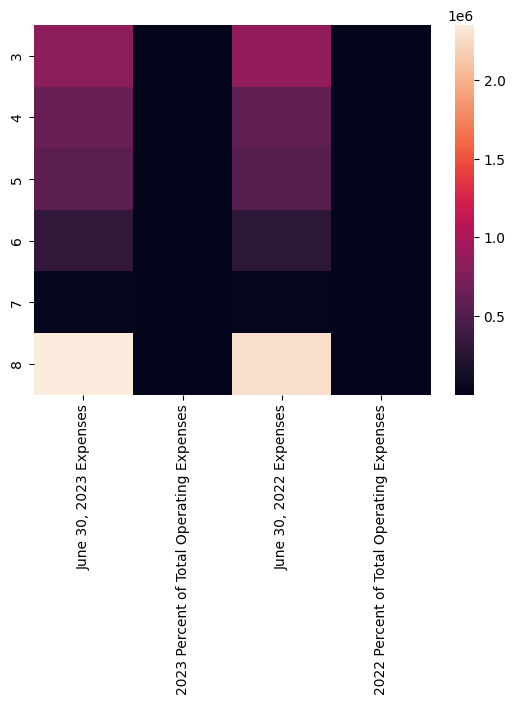

       June 30, 2023 Expenses  2023 Percent of Total Operating Expenses  \
count            6.000000e+00                                  6.000000   
mean             7.844100e+05                                 33.333333   
std              8.166697e+05                                 34.737108   
min              2.942200e+04                                  1.000000   
25%              3.690462e+05                                 15.750000   
50%              5.982455e+05                                 25.500000   
75%              7.755642e+05                                 33.000000   
max              2.353230e+06                                100.000000   

       June 30, 2022 Expenses  2022 Percent of Total Operating Expenses  
count            6.000000e+00                                  6.000000  
mean             7.584730e+05                                 33.333333  
std              7.949345e+05                                 35.006666  
min              2.505100e+0

<Axes: >

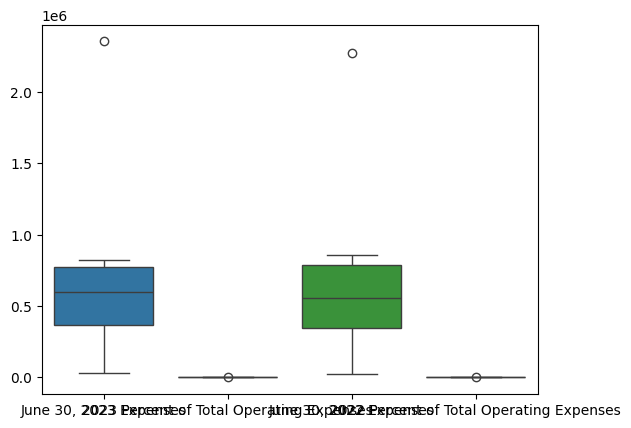

In [143]:
#subset dataframe to create a heatmap to visualize missing data even though there were no missing data. Keep numeric value columns
expenses23_df_subset = expenses23_df[[ "June 30, 2023 Expenses", "2023 Percent of Total Operating Expenses", "June 30, 2022 Expenses", "2022 Percent of Total Operating Expenses"]]

#create heatmap of dataframe
sns.heatmap(expenses23_df_subset)
plt.show() #show heatmap
 

#find outliers in dataframe using describe()
print(expenses23_df.describe())

#create boxplot of dataframe without na to visualize outliers
sns.boxplot(data=expenses23_df)

In [144]:
#export cleaned 2023 operating expenses dataframe in csv file
expenses23_df.to_csv("../../data/processed-data/Budget2023_operating_expenses.csv")

In [135]:
#extract debt table from pdf on page 12 using 'stream" because table data has no border
debt_table = camelot.read_pdf(pdf_file, flavor='stream', pages='12')

#if it is a table and table is found, then extract table and convert the table into a dataframe
if debt_table:
    debts23_df = debt_table[0].df
    print(debts23_df)
else:
    print("no tables found")

                                                   0  1          2  3  \
0  Bonds and notes outstanding for the fiscal yea...                    
1                                                             2023      
2                General Transportation System bonds  $     99,470  $   
3                                 Revenue bonds, net     4,248,525      
4                                              RRIFs       647,545      
5                                   Commercial paper       125,000      
6                                               BABs       394,300      
7                                                     $  5,514,840  $   

           4  
0             
1       2022  
2    110,210  
3  4,441,827  
4    370,392  
5     40,000  
6    402,550  
7  5,364,979  


In [146]:
#drop unneeded columns from the dataframe. Drop columns with default header 1
debts23_df.drop([1,3], axis=1, inplace=True)
print(debts23_df)

                                                   0          2          4
0  Bonds and notes outstanding for the fiscal yea...                      
1                                                          2023       2022
2                General Transportation System bonds     99,470    110,210
3                                 Revenue bonds, net  4,248,525  4,441,827
4                                              RRIFs    647,545    370,392
5                                   Commercial paper    125,000     40,000
6                                               BABs    394,300    402,550
7                                                     5,514,840  5,364,979


In [148]:
#rename column headers in dataframe
debts23_df.rename(columns={0:"Sources of Debt", 2:"June 30, 2023 Debt", 4:"June 30, 2022 Debt"}, inplace=True)


In [149]:
#drop rows indexes 0 because they had blank values and other rows were correctly renamed
debts23_df.drop(0, inplace=True)

In [150]:
#rename total value column "Sources of Debt" because the table was missing a label for the total debt at bottom of dataframe
debts23_df.at[7, "Sources of Debt"] = "Total Debt"


In [151]:
#strip white spaces, $ and % characters from values in the dataframe
debts23_df["June 30, 2023 Debt"] = debts23_df["June 30, 2023 Debt"].str.strip().str.replace(",", "")
debts23_df["June 30, 2022 Debt"] = debts23_df["June 30, 2022 Debt"].str.strip().str.replace(",", "")
#print(expenses23_df)

In [153]:
print(debts23_df.dtypes) #print the data types of columns in dataframe

debts23_df["Sources of Debt"] = debts23_df["Sources of Debt"].astype(str)
debts23_df["June 30, 2023 Debt"] = debts23_df["June 30, 2023 Debt"].astype(int)
debts23_df["June 30, 2022 Debt"] = debts23_df["June 30, 2022 Debt"].astype(int)

print("After data type conversion", debts23_df.dtypes)


Sources of Debt       object
June 30, 2023 Debt    object
June 30, 2022 Debt    object
dtype: object
After data type conversion Sources of Debt       object
June 30, 2023 Debt     int64
June 30, 2022 Debt     int64
dtype: object


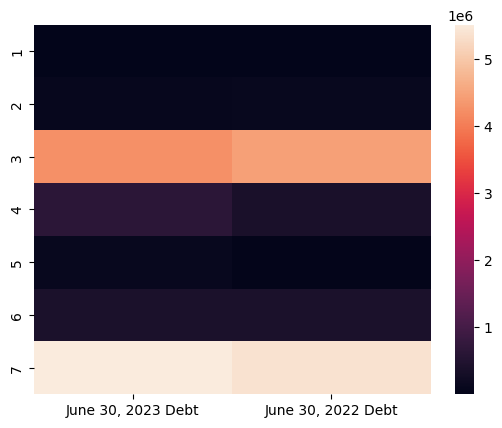

       June 30, 2023 Debt  June 30, 2022 Debt
count        7.000000e+00        7.000000e+00
mean         1.575958e+06        1.533140e+06
std          2.297761e+06        2.322792e+06
min          2.023000e+03        2.022000e+03
25%          1.122350e+05        7.510500e+04
50%          3.943000e+05        3.703920e+05
75%          2.448035e+06        2.422188e+06
max          5.514840e+06        5.364979e+06


<Axes: >

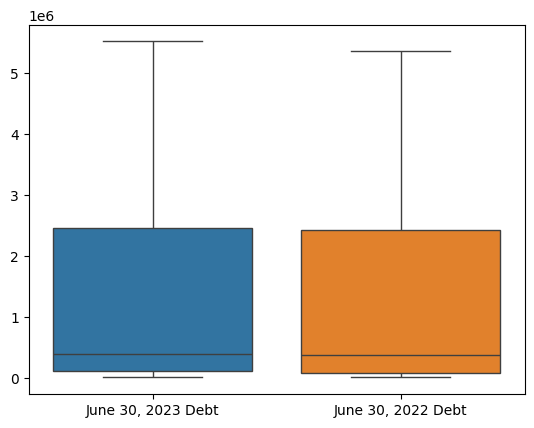

In [154]:
#subset dataframe to create a heatmap to visualize missing data even though there were no missing data. Keep numeric value columns
debts23_df_subset = debts23_df[["June 30, 2023 Debt", "June 30, 2022 Debt"]]

#create heatmap of dataframe
sns.heatmap(debts23_df_subset)
plt.show() #show heatmap
 

#find outliers in dataframe using describe()
print(debts23_df.describe())

#create boxplot of dataframe without na to visualize outliers
sns.boxplot(data=debts23_df)

In [155]:
#export cleaned 2023 debts dataframe in csv file
debts23_df.to_csv("../../data/processed-data/Budget2023_debts.csv")

In [194]:
#set pdf file path for the 2021 budget pdf file
pdf_file21 = "../../data/raw-data/fy21-audited-financial-statements.pdf"

#extract table from pdf on page 9 using 'stream" because table data has no border
table_file21_p1 = camelot.read_pdf(pdf_file21, flavor='stream', pages='7')

#if it is a table and table is found, then convert the table into a dataframe
if table_file21_p1:
    net21_p1_df = table_file21_p1[1].df
    print(net21_p1_df)
else:
    print("no tables found")

#extract table from pdf on page 9 using 'stream" because table data has no border
table_file21 = camelot.read_pdf(pdf_file21, flavor='stream', pages='8')

#if it is a table and table is found, then convert the table into a dataframe
if table_file21:
    net21_df = table_file21[0].df
    print(net21_df)
else:
    print("no tables found")

#stack the two dataframes using concat becuase the table was split into two pages on the pdf file
combined_net21_df = pd.concat([net21_p1_df, net21_df])

combined_net21_df_index = combined_net21_df.reset_index()

print(combined_net21_df_index)

                                                  0  1          2          3
0                                                         June 30           
1                                                            2021       2020
2                                Operating revenue:                         
3                       Revenue from transportation  $    167,114    545,650
4                                             Other        39,075     86,928
5                          Total operating revenues       206,189    632,578
6                               Operating expenses:                         
7                           Transportation services       838,897    966,475
8                          Other operating expenses       853,639    842,397
9  Total operating expenses, excluding depreciation     1,692,536  1,808,872
                                                    0  1            2  \
0                                                                2021   
1      

In [195]:
#drop unneeded columns from the df dataframe. Drop columns with default header 1 and 4
combined_net21_df_index.drop([1,4, "index"], axis=1, inplace=True)
#print(combined_net21_df) #print dataframe to check columns dropped

In [196]:
#rename headers in dataframe
combined_net21_df_index.rename(columns={0:"Statements of Revenue, Expenses and Changes in Net Position", 2:"June 30, 2021", 3:"June 30, 2020"}, inplace=True)
print(combined_net21_df_index)

   Statements of Revenue, Expenses and Changes in Net Position June 30, 2021  \
0                                                                    June 30   
1                                                                       2021   
2                                  Operating revenue:                          
3                         Revenue from transportation                167,114   
4                                               Other                 39,075   
5                            Total operating revenues                206,189   
6                                 Operating expenses:                          
7                             Transportation services                838,897   
8                            Other operating expenses                853,639   
9    Total operating expenses, excluding depreciation              1,692,536   
10                                                                      2021   
11                      Depreciation and

In [197]:
#rename some values in the "Statements of Revenue, Expenses and Changes in Net Position" column because the table was formatted with too much space for those cells
combined_net21_df_index.at[4,"Statements of Revenue, Expenses and Changes in Net Position"] = "Other revenue"
combined_net21_df_index.at[13,"Statements of Revenue, Expenses and Changes in Net Position"] = "Total operating expenses, including depreciation and amortization"
print(combined_net21_df_index)

   Statements of Revenue, Expenses and Changes in Net Position June 30, 2021  \
0                                                                    June 30   
1                                                                       2021   
2                                  Operating revenue:                          
3                         Revenue from transportation                167,114   
4                                       Other revenue                 39,075   
5                            Total operating revenues                206,189   
6                                 Operating expenses:                          
7                             Transportation services                838,897   
8                            Other operating expenses                853,639   
9    Total operating expenses, excluding depreciation              1,692,536   
10                                                                      2021   
11                      Depreciation and

In [198]:
#drop rows index 6 and 11 because they had blank values and other rows were correctly renamed
combined_net21_df_index.drop([0,1,2,6,10,12], inplace=True)
print(combined_net21_df_index)

   Statements of Revenue, Expenses and Changes in Net Position June 30, 2021  \
3                         Revenue from transportation                167,114   
4                                       Other revenue                 39,075   
5                            Total operating revenues                206,189   
7                             Transportation services                838,897   
8                            Other operating expenses                853,639   
9    Total operating expenses, excluding depreciation              1,692,536   
11                      Depreciation and amortization                439,544   
13  Total operating expenses, including depreciati...              2,132,080   
14                                     Operating loss            (1,925,891)   
15                          Nonoperating revenue, net              2,280,135   
16     Income before capital grants and contributions                354,244   
17                   Capital grants and 

In [199]:
#check the data types of columns in the dataframe
print(combined_net21_df_index.dtypes)
combined_net21_df_index["Statements of Revenue, Expenses and Changes in Net Position"] = combined_net21_df_index["Statements of Revenue, Expenses and Changes in Net Position"].astype(str) #transform data type from objects into strings in this column

combined_net21_df_index["June 30, 2021"] = combined_net21_df_index["June 30, 2021"].str.replace(",", "") #remove comma characters in column "June 30, 2021"
combined_net21_df_index["June 30, 2020"] = combined_net21_df_index["June 30, 2020"].str.replace(",", "") #remove comma characters in column "June 30, 2020"

combined_net21_df_index["June 30, 2021"] = combined_net21_df_index["June 30, 2021"].str.replace("(", "") #remove '(' characters in column "June 30, 2021"
combined_net21_df_index["June 30, 2020"] = combined_net21_df_index["June 30, 2020"].str.replace("(", "") #remove '(' characters in column "June 30, 2020"

combined_net21_df_index["June 30, 2021"] = combined_net21_df_index["June 30, 2021"].str.replace(")", "") #remove ')' characters in column "June 30, 2021"
combined_net21_df_index["June 30, 2020"] = combined_net21_df_index["June 30, 2020"].str.replace(")", "") #remove ')' characters in column "June 30, 2020"


combined_net21_df_index["June 30, 2021"] = combined_net21_df_index["June 30, 2021"].astype(int) #convert "June 30, 2021" column data type to numeric
combined_net21_df_index["June 30, 2020"] = combined_net21_df_index["June 30, 2020"].astype(int) #convert "June 30, 2020" column data type to numeric

print("After conversion", combined_net21_df_index.dtypes)

Statements of Revenue, Expenses and Changes in Net Position    object
June 30, 2021                                                  object
June 30, 2020                                                  object
dtype: object
After conversion Statements of Revenue, Expenses and Changes in Net Position    object
June 30, 2021                                                   int64
June 30, 2020                                                   int64
dtype: object


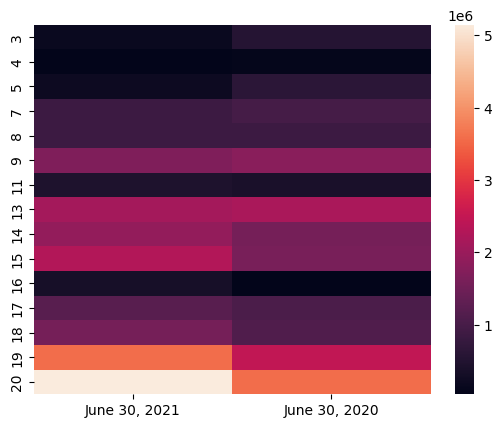

       June 30, 2021  June 30, 2020
count   1.500000e+01   1.500000e+01
mean    1.495777e+06   1.259524e+06
std     1.409425e+06   9.659837e+05
min     3.907500e+04   5.408000e+04
25%     3.968940e+05   5.891140e+05
50%     1.213708e+06   1.051626e+06
75%     2.028986e+06   1.711000e+06
max     5.146804e+06   3.578852e+06


<Axes: >

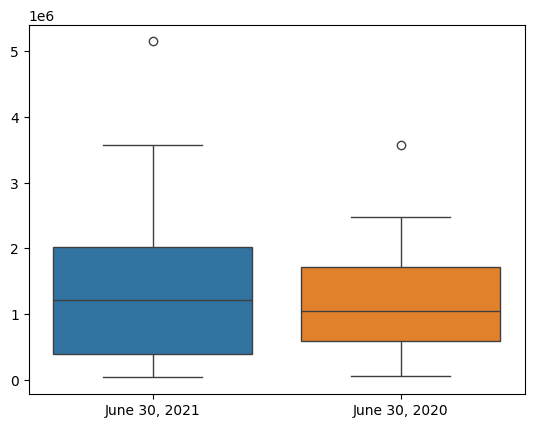

In [441]:
#subset dataframe to create a heatmap to visualize missing data even though there were no missing data. Keep numeric value columns
combined_net21_df_index_subset = combined_net21_df_index[[ "June 30, 2021", "June 30, 2020"]]

#create heatmap of dataframe
sns.heatmap(combined_net21_df_index_subset)
plt.show() #show heatmap


#find outliers in dataframe using describe()
print(combined_net21_df_index.describe())

#create boxplot of dataframe without na to visualize outliers
sns.boxplot(data=combined_net21_df_index)


In [201]:
#export cleaned 2021-2020 debts dataframe in csv file
combined_net21_df_index.to_csv("../../data/processed-data/Budget2021_2020_net_positions.csv")

In [267]:
#extract table from pdf on page 9 using 'stream" because table data has no border: revenue table
table21revenue = camelot.read_pdf(pdf_file21, flavor='stream', pages='9')

#if it is a table and table is found, then convert the table into a dataframe
if table21revenue:
    revenue21_df = table21revenue[0].df
    print("Revenue table 2021 \n", revenue21_df)
else:
    print("no tables found")


Revenue table 2021 
                  0  1        2         3        4         5
0            2020:                                         
1                                Percent            Percent
2                         2021  of total     2020  of total
3              Bus  $   36,713    18 % $   86,296      14 %
4           Subway      93,635        45  242,164        38
5    Commuter rail      33,109        16  203,165        32
6  Other passenger       3,657         2   14,025         2
7  Other operating      39,075        19   86,928        14
8                   $  206,189   100 % $  632,578     100 %


In [268]:
#extract table from pdf on page 9 using 'stream" because table data has no border: expenses table
table21expenses = camelot.read_pdf(pdf_file21, flavor='stream', pages='9')

#if it is a table and table is found, then convert the table into a dataframe
if table21expenses:
    expenses21_df = table21expenses[1].df
    print("Expenses table 2021 \n", expenses21_df)
else:
    print("no tables found")


Expenses table 2021 
                                0  1          2         3          4         5
0                      and 2019:                                             
1                                                Percent              Percent
2                                         2021  of total       2020  of total
3             Wages and benefits  $    838,897    39 % $    966,475      44 %
4                  Commuter rail       542,226        25    546,624        25
5  Depreciation and amortization       439,544        21    382,754        18
6          Material and supplies       288,865        14    266,515        12
7                Other operating        22,548         1     29,258         1
8                                 $  2,132,080   100 % $  2,191,626     100 %


In [269]:
#drop unneeded columns from the df dataframe. Drop columns with default header 1
revenue21_df = revenue21_df.drop(1, axis=1)
#print(revenue21_df) #print dataframe to check columns dropped

#rename column headers in dataframe
revenue21_df = revenue21_df.rename(columns={0:"Sources of Operating Revenue", 2:"June 30, 2021 Revenue", 3:"2021 Percent of Total Operating Revenue", 4:"June 30, 2020 Revenue", 5:"2020 Percent of Total Operating Revenue"})
#print(revenue21_df)

#drop rows indexs because they had blank values and other rows were correctly renamed
revenue21_df.drop([0,1,2], inplace=True)
print(revenue21_df)


  Sources of Operating Revenue June 30, 2021 Revenue  \
3                          Bus                36,713   
4                       Subway                93,635   
5                Commuter rail                33,109   
6              Other passenger                 3,657   
7              Other operating                39,075   
8                                            206,189   

  2021 Percent of Total Operating Revenue June 30, 2020 Revenue  \
3                                  18 % $                86,296   
4                                      45               242,164   
5                                      16               203,165   
6                                       2                14,025   
7                                      19                86,928   
8                                 100 % $               632,578   

  2020 Percent of Total Operating Revenue  
3                                    14 %  
4                                      38  
5    

In [270]:
#rename some values in the "Sources of Operating Revenue" column because the table was formatted with too much space for those cells
revenue21_df.at[8,"Sources of Operating Revenue"] = "Total Operating Revenue"
print(revenue21_df)


  Sources of Operating Revenue June 30, 2021 Revenue  \
3                          Bus                36,713   
4                       Subway                93,635   
5                Commuter rail                33,109   
6              Other passenger                 3,657   
7              Other operating                39,075   
8      Total Operating Revenue               206,189   

  2021 Percent of Total Operating Revenue June 30, 2020 Revenue  \
3                                  18 % $                86,296   
4                                      45               242,164   
5                                      16               203,165   
6                                       2                14,025   
7                                      19                86,928   
8                                 100 % $               632,578   

  2020 Percent of Total Operating Revenue  
3                                    14 %  
4                                      38  
5    

  Sources of Operating Revenue June 30, 2021 Revenue  \
3                          Bus                 36713   
4                       Subway                 93635   
5                Commuter rail                 33109   
6              Other passenger                  3657   
7              Other operating                 39075   
8      Total Operating Revenue                206189   

  2021 Percent of Total Operating Revenue June 30, 2020 Revenue  \
3                                    18                   86296   
4                                      45                242164   
5                                      16                203165   
6                                       2                 14025   
7                                      19                 86928   
8                                   100                  632578   

  2020 Percent of Total Operating Revenue  
3                                     14   
4                                      38  
5    

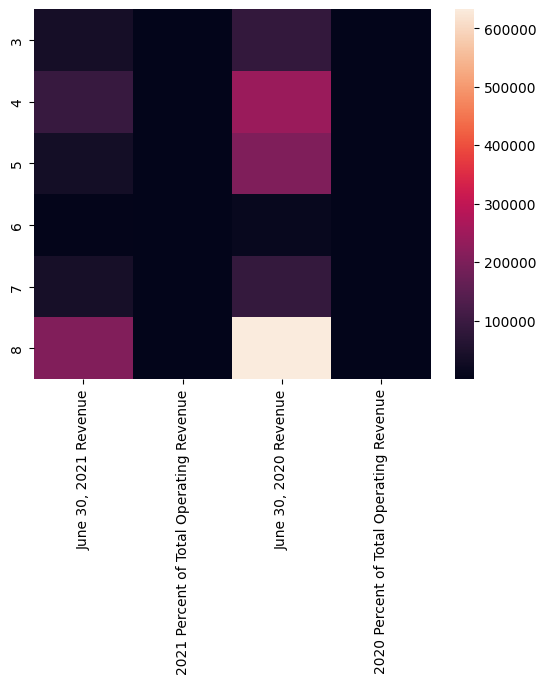

       June 30, 2021 Revenue  2021 Percent of Total Operating Revenue  \
count               6.000000                                 6.000000   
mean            68729.666667                                33.333333   
std             73379.961828                                35.505868   
min              3657.000000                                 2.000000   
25%             34010.000000                                16.500000   
50%             37894.000000                                18.500000   
75%             79995.000000                                38.500000   
max            206189.000000                               100.000000   

       June 30, 2020 Revenue  2020 Percent of Total Operating Revenue  
count               6.000000                                 6.000000  
mean           210859.333333                                33.333333  
std            222937.019316                                35.206060  
min             14025.000000                          

<Axes: >

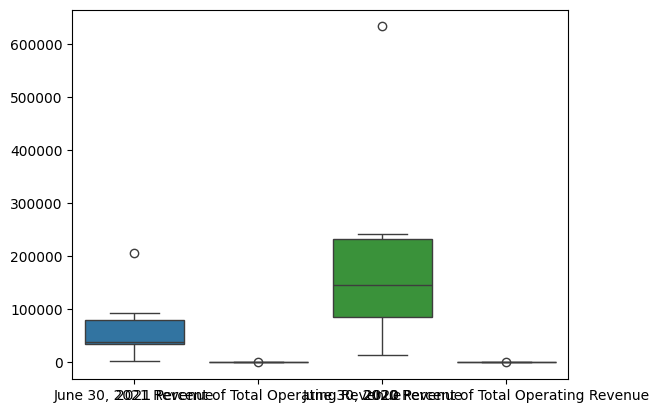

In [271]:
#strip white spaces, $ and % characters from values in the dataframe
revenue21_df["2021 Percent of Total Operating Revenue"] = revenue21_df["2021 Percent of Total Operating Revenue"].str.strip().str.replace("$", "").str.replace("%", "")
revenue21_df["2020 Percent of Total Operating Revenue"] = revenue21_df["2020 Percent of Total Operating Revenue"].str.strip().str.replace("$", "").str.replace("%", "")

revenue21_df["June 30, 2021 Revenue"] = revenue21_df["June 30, 2021 Revenue"].str.strip().str.replace(",", "")
revenue21_df["June 30, 2020 Revenue"] = revenue21_df["June 30, 2020 Revenue"].str.strip().str.replace(",", "")
print(revenue21_df)

print(revenue21_df.dtypes) #print the data types of columns in dataframe
revenue21_df["Sources of Operating Revenue"] = revenue21_df["Sources of Operating Revenue"].astype(str)
revenue21_df["June 30, 2021 Revenue"] = revenue21_df["June 30, 2021 Revenue"].astype(int)
revenue21_df["2021 Percent of Total Operating Revenue"] = revenue21_df["2021 Percent of Total Operating Revenue"].astype(int)
revenue21_df["June 30, 2020 Revenue"] = revenue21_df["June 30, 2020 Revenue"].astype(int)
revenue21_df["2020 Percent of Total Operating Revenue"] = revenue21_df["2020 Percent of Total Operating Revenue"].astype(int)

print("After data type conversion", revenue21_df.dtypes)

#subset dataframe to create a heatmap to visualize missing data even though there were no missing data. Keep numeric value columns
revenue21_df_subset = revenue21_df[["June 30, 2021 Revenue", "2021 Percent of Total Operating Revenue", "June 30, 2020 Revenue", "2020 Percent of Total Operating Revenue"]]

#create heatmap of dataframe
sns.heatmap(revenue21_df_subset)
plt.show() #show heatmap

#find outliers in dataframe using describe()
print(revenue21_df.describe())

#create boxplot of dataframe without na to visualize outliers
sns.boxplot(data=revenue21_df)

In [272]:
#export cleaned 2021-2020 revenue dataframe in csv file
revenue21_df.to_csv("../../data/processed-data/Budget2021_2020_revenue.csv")

In [273]:
#2021-2020 expenses
#drop unneeded columns from the df dataframe. Drop columns with default header 1
expenses21_df = expenses21_df.drop(1, axis=1)

#rename column headers in dataframe
expenses21_df = expenses21_df.rename(columns={0:"Sources of Operating Expenses", 2:"June 30, 2021 Expenses", 3:"2021 Percent of Total Operating Expenses", 4:"June 30, 2020 Expenses", 5:"2020 Percent of Total Operating Expenses"})
print(expenses21_df)

   Sources of Operating Expenses June 30, 2021 Expenses  \
0                      and 2019:                          
1                                                         
2                                                  2021   
3             Wages and benefits                838,897   
4                  Commuter rail                542,226   
5  Depreciation and amortization                439,544   
6          Material and supplies                288,865   
7                Other operating                 22,548   
8                                             2,132,080   

  2021 Percent of Total Operating Expenses June 30, 2020 Expenses  \
0                                                                   
1                                  Percent                          
2                                 of total                   2020   
3                                   39 % $                966,475   
4                                       25                546,62

In [274]:
#drop rows indexs because they had blank values and other rows were correctly renamed
expenses21_df.drop([0,1,2], inplace=True)
#print(expenses21_df)

In [275]:
#rename some values in the "Sources of Operating Expenses" column because the table was formatted with too much space for those cells
expenses21_df.at[8,"Sources of Operating Expenses"] = "Total Operating Expenses"
#print(expenses21_df)

Sources of Operating Expenses               object
June 30, 2021 Expenses                      object
2021 Percent of Total Operating Expenses    object
June 30, 2020 Expenses                      object
2020 Percent of Total Operating Expenses    object
dtype: object
After data type conversion Sources of Operating Expenses               object
June 30, 2021 Expenses                       int64
2021 Percent of Total Operating Expenses     int64
June 30, 2020 Expenses                       int64
2020 Percent of Total Operating Expenses     int64
dtype: object
   Sources of Operating Expenses  June 30, 2021 Expenses  \
3             Wages and benefits                  838897   
4                  Commuter rail                  542226   
5  Depreciation and amortization                  439544   
6          Material and supplies                  288865   
7                Other operating                   22548   
8       Total Operating Expenses                 2132080   

   2021 Percen

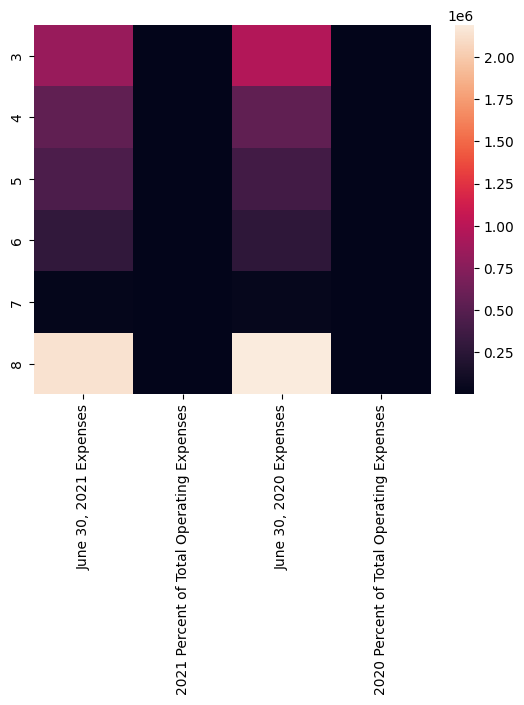

       June 30, 2021 Expenses  2021 Percent of Total Operating Expenses  \
count            6.000000e+00                                  6.000000   
mean             7.106933e+05                                 33.333333   
std              7.470157e+05                                 34.978088   
min              2.254800e+04                                  1.000000   
25%              3.265348e+05                                 15.750000   
50%              4.908850e+05                                 23.000000   
75%              7.647292e+05                                 35.500000   
max              2.132080e+06                                100.000000   

       June 30, 2020 Expenses  2020 Percent of Total Operating Expenses  
count            6.000000e+00                                  6.000000  
mean             7.305420e+05                                 33.333333  
std              7.813237e+05                                 35.674454  
min              2.925800e+0

<Axes: >

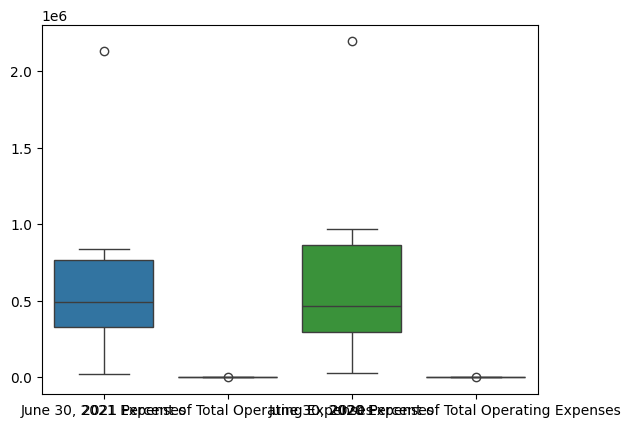

In [276]:
#strip white spaces, $ and % characters from values in the dataframe
expenses21_df["2021 Percent of Total Operating Expenses"] = expenses21_df["2021 Percent of Total Operating Expenses"].str.strip().str.replace("$", "").str.replace("%", "")
expenses21_df["2020 Percent of Total Operating Expenses"] = expenses21_df["2020 Percent of Total Operating Expenses"].str.strip().str.replace("$", "").str.replace("%", "")

expenses21_df["June 30, 2021 Expenses"] = expenses21_df["June 30, 2021 Expenses"].str.strip().str.replace(",", "")
expenses21_df["June 30, 2020 Expenses"] = expenses21_df["June 30, 2020 Expenses"].str.strip().str.replace(",", "")

print(expenses21_df.dtypes) #print the data types of columns in dataframe
expenses21_df["Sources of Operating Expenses"] = expenses21_df["Sources of Operating Expenses"].astype(str)
expenses21_df["June 30, 2021 Expenses"] = expenses21_df["June 30, 2021 Expenses"].astype(int)
expenses21_df["2021 Percent of Total Operating Expenses"] = expenses21_df["2021 Percent of Total Operating Expenses"].astype(int)
expenses21_df["June 30, 2020 Expenses"] = expenses21_df["June 30, 2020 Expenses"].astype(int)
expenses21_df["2020 Percent of Total Operating Expenses"] = expenses21_df["2020 Percent of Total Operating Expenses"].astype(int)

print("After data type conversion", expenses21_df.dtypes)

print(expenses21_df)

#subset dataframe to create a heatmap to visualize missing data even though there were no missing data. Keep numeric value columns
expenses21_df_subset = expenses21_df[["June 30, 2021 Expenses", "2021 Percent of Total Operating Expenses", "June 30, 2020 Expenses", "2020 Percent of Total Operating Expenses"]]

#create heatmap of dataframe
sns.heatmap(expenses21_df_subset)
plt.show() #show heatmap

#find outliers in dataframe using describe()
print(expenses21_df.describe())

#create boxplot of dataframe without na to visualize outliers
sns.boxplot(data=expenses21_df)

In [277]:
#export cleaned 2021-2020 expenses dataframe in csv file
expenses21_df.to_csv("../../data/processed-data/Budget2021_2020_expenses.csv")

In [345]:
#extract debt table for 2021 from the 2022 financial statement audit because library was not able to correctly extract debt table from the 2021 financial statement pdf file.

#set pdf file path for the 2022 budget pdf file
pdf_file22 = "../../data/raw-data/fy22-audited-financial-statement.pdf"

#extract table from pdf on page 11 using 'stream" because table data has no border: debt table
table21debts = camelot.read_pdf(pdf_file22, flavor='stream', pages='11')

#if it is a table and table is found, then convert the table into a dataframe
if table21debts:
    debts21_df = table21debts[0].df
    print(debts21_df)
else:
    print("no tables found")

                                                   0  1          2          3
0                                               Debt                         
1  Bonds and notes outstanding for the fiscal yea...                         
2                                                             2022       2021
3                General Transportation System bonds  $    110,210    121,165
4                                      Revenue bonds     4,441,827  4,607,636
5                                             RRIF's       370,392          —
6                                   Commercial paper        40,000    200,000
7                                              BAB’s       402,550    420,545
8                                                     $  5,364,979  5,349,346


In [346]:
#drop unneeded columns from the df dataframe. Drop columns with default header 1
#drop 2022 since that was already extracted in the previous part of the code
debts21_df = debts21_df.drop([1,2], axis=1)
#print(debts21_df)

In [347]:
#rename column headers in dataframe
debts21_df = debts21_df.rename(columns={0:"Sources of Debt", 3:"June 30, 2021 Debts"})
#print(debts21_df)

In [348]:
#drop rows indexs because they had blank values and other rows were correctly renamed
debts21_df.drop([0,1,2], inplace=True)
#print(debts21_df)

In [349]:
#rename some values in the "Sources of Debt" column because the table was formatted with too much space for those cells
debts21_df.at[8,"Sources of Debt"] = "Total Debts"
print(debts21_df)


                       Sources of Debt June 30, 2021 Debts
3  General Transportation System bonds             121,165
4                        Revenue bonds           4,607,636
5                               RRIF's                   —
6                     Commercial paper             200,000
7                                BAB’s             420,545
8                          Total Debts           5,349,346


In [351]:
#strip white spaces and comma characters from values in the dataframe
#debts21_df["June 30, 2021 Debts"] = debts21_df["June 30, 2021 Debts"].str.strip().replace('—',np.nan)

#decided to replace missing value with "0" to convert column to integers and keep row count the same for eaiser joining later on with other dataframes
debts21_df["June 30, 2021 Debts"] = debts21_df["June 30, 2021 Debts"].str.strip().replace('—',np.nan)
#debts21_df["June 30, 2021 Debts"] = debts21_df["June 30, 2021 Debts"].fillna(0)

print(debts21_df)

                       Sources of Debt June 30, 2021 Debts
3  General Transportation System bonds              121165
4                        Revenue bonds             4607636
5                               RRIF's                 NaN
6                     Commercial paper              200000
7                                BAB’s              420545
8                          Total Debts             5349346


                       Sources of Debt June 30, 2021 Debts
3  General Transportation System bonds              121165
4                        Revenue bonds             4607636
5                               RRIF's                 NaN
6                     Commercial paper              200000
7                                BAB’s              420545
8                          Total Debts             5349346
Sources of Debt        object
June 30, 2021 Debts    object
dtype: object
After data type conversion Sources of Debt        object
June 30, 2021 Debts     int64
dtype: object


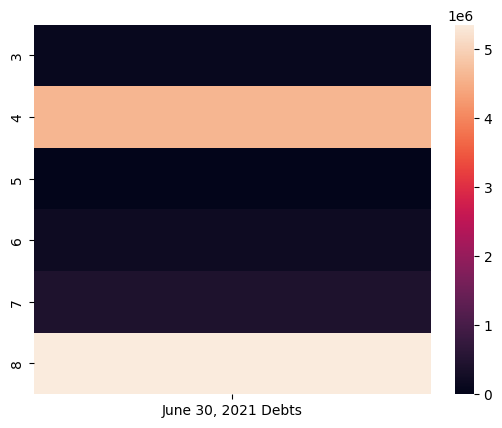

       June 30, 2021 Debts
count         6.000000e+00
mean          1.783115e+06
std           2.489994e+06
min           0.000000e+00
25%           1.408738e+05
50%           3.102725e+05
75%           3.560863e+06
max           5.349346e+06


<Axes: >

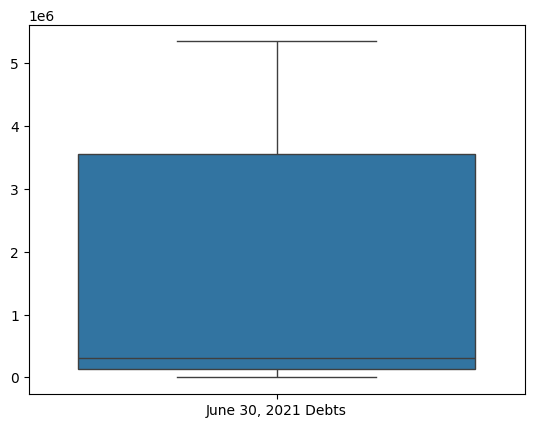

In [352]:
#strip white spaces and comma characters from values in the dataframe
debts21_df["June 30, 2021 Debts"] = debts21_df["June 30, 2021 Debts"].str.strip().str.replace(",", "")
print(debts21_df)

print(debts21_df.dtypes) #print the data types of columns in dataframe
debts21_df["Sources of Debt"] = debts21_df["Sources of Debt"].astype(str)
debts21_df["June 30, 2021 Debts"] = debts21_df["June 30, 2021 Debts"].astype(float)
debts21_df["June 30, 2021 Debts"] = debts21_df["June 30, 2021 Debts"].fillna(0).astype(int)
print("After data type conversion", debts21_df.dtypes)

#subset dataframe to create a heatmap to visualize missing data even though there were no missing data. Keep numeric value columns
debts21_df_subset = debts21_df[[ "June 30, 2021 Debts"]]

#create heatmap of dataframe
sns.heatmap(debts21_df_subset)
plt.show() #show heatmap

#find outliers in dataframe using describe()
print(debts21_df.describe())

#create boxplot of dataframe without na to visualize outliers
sns.boxplot(data=debts21_df)

In [355]:
debts21_df.to_csv("../../data/processed-data/Budget2021_debts.csv")

In [369]:
#extract net position table for 2020 and 2019 from the 2020 financial statement audit

#set pdf file path for the 2022 budget pdf file
pdf_file20 = "../../data/raw-data/fy20-financial-audit.pdf"

#extract table from pdf on page 11 using 'stream" because table data has no border: debt table
table20_net = camelot.read_pdf(pdf_file20, flavor='stream', pages='8')

#if it is a table and table is found, then convert the table into a dataframe
if table20_net:
    net20_df = table20_net [0].df
    print(net20_df)
else:
    print("no tables found")

                                                    0  1            2  \
0                                                             June 30   
1                                                                2020   
2                                  Operating revenue:                   
3                         Revenue from transportation  $      545,650   
4                                               Other          86,928   
5                            Total operating revenues         632,578   
6                                 Operating expenses:                   
7                             Transportation services         966,475   
8                            Other operating expenses         842,397   
9    Total operating expenses, excluding depreciation       1,808,872   
10                      Depreciation and amortization         382,754   
11  Total operating expenses, including depreciati...                   
12                                       amortizati

In [370]:
#drop unneeded columns from the df dataframe. Drop columns with default header 1
net20_df = net20_df.drop([1,2], axis=1)

#rename column headers in dataframe
net20_df = net20_df.rename(columns={0:"Statements of Revenue, Expenses and Changes in Net Position", 3:"June 30, 2019 Net Positions"})

#drop rows indexs because they had blank values and other rows were correctly renamed
net20_df = net20_df.drop([0,1,2,6,11])
print(net20_df)


   Statements of Revenue, Expenses and Changes in Net Position  \
3                         Revenue from transportation            
4                                               Other            
5                            Total operating revenues            
7                             Transportation services            
8                            Other operating expenses            
9    Total operating expenses, excluding depreciation            
10                      Depreciation and amortization            
12                                       amortization            
13                                     Operating loss            
14                          Nonoperating revenue, net            
15  Gain (loss) before capital grants and contribu...            
16                   Capital grants and contributions            
17                           Increase in net position            
18                    Beginning of year, net position            
19        

In [371]:
#rename some values in the "Sources of Operating Revenue" column because the table was formatted with too much space for those cells
net20_df.at[4,"Statements of Revenue, Expenses and Changes in Net Position"] = "Other Revenue"
net20_df.at[12,"Statements of Revenue, Expenses and Changes in Net Position"] = "Total operating expenses, including depreciation and amortization"
print(net20_df)

   Statements of Revenue, Expenses and Changes in Net Position  \
3                         Revenue from transportation            
4                                       Other Revenue            
5                            Total operating revenues            
7                             Transportation services            
8                            Other operating expenses            
9    Total operating expenses, excluding depreciation            
10                      Depreciation and amortization            
12  Total operating expenses, including depreciati...            
13                                     Operating loss            
14                          Nonoperating revenue, net            
15  Gain (loss) before capital grants and contribu...            
16                   Capital grants and contributions            
17                           Increase in net position            
18                    Beginning of year, net position            
19        

   Statements of Revenue, Expenses and Changes in Net Position  \
3                         Revenue from transportation            
4                                       Other Revenue            
5                            Total operating revenues            
7                             Transportation services            
8                            Other operating expenses            
9    Total operating expenses, excluding depreciation            
10                      Depreciation and amortization            
12  Total operating expenses, including depreciati...            
13                                     Operating loss            
14                          Nonoperating revenue, net            
15  Gain (loss) before capital grants and contribu...            
16                   Capital grants and contributions            
17                           Increase in net position            
18                    Beginning of year, net position            
19        

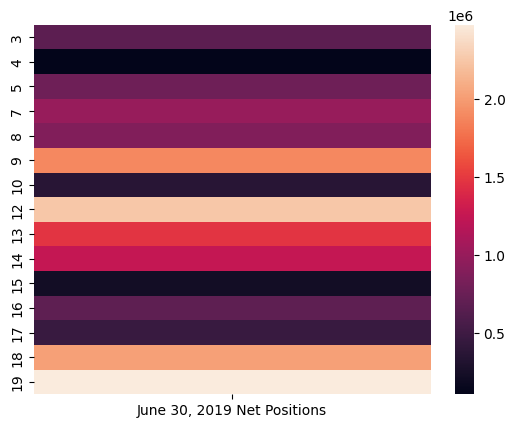

       June 30, 2019 Net Positions
count                 1.500000e+01
mean                  1.100428e+06
std                   7.576051e+05
min                   1.054900e+05
25%                   5.656795e+05
50%                   8.820250e+05
75%                   1.677306e+06
max                   2.473146e+06


<Axes: >

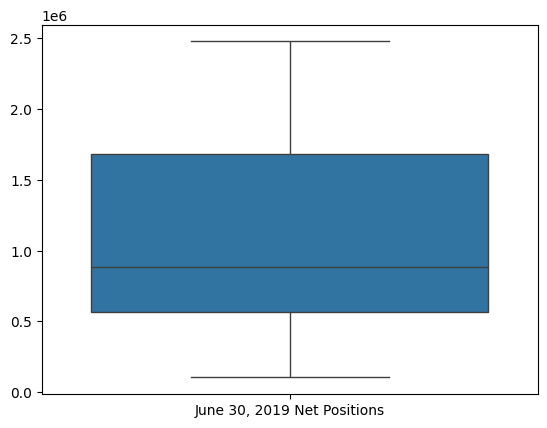

In [372]:
#strip white spaces and comma characters from values in the dataframe
net20_df["June 30, 2019 Net Positions"] = net20_df["June 30, 2019 Net Positions"].str.strip().str.replace(",", "").str.replace("(", "").str.replace(")", "")
print(net20_df)

print(net20_df.dtypes) #print the data types of columns in dataframe
net20_df["Statements of Revenue, Expenses and Changes in Net Position"] = net20_df["Statements of Revenue, Expenses and Changes in Net Position"].astype(str)
net20_df["June 30, 2019 Net Positions"] = net20_df["June 30, 2019 Net Positions"].astype(int)
print("After data type conversion", net20_df.dtypes)

#subset dataframe to create a heatmap to visualize missing data even though there were no missing data. Keep numeric value columns
net20_df_subset = net20_df[["June 30, 2019 Net Positions"]]

#create heatmap of dataframe
sns.heatmap(net20_df_subset)
plt.show() #show heatmap

#find outliers in dataframe using describe()
print(net20_df.describe())

#create boxplot of dataframe without na to visualize outliers
sns.boxplot(data=net20_df)

In [373]:
#export cleaned 2019 net positions dataframe to csv file
net20_df.to_csv("../../data/processed-data/Budget2019_net_positions.csv")

In [385]:
#not able to get revenue table for 2019 because the camelot library was only able to extract the first half of the page which was the text instead of the table.
#set pdf file path for the 2019 budget pdf file
pdf_file19 = "../../data/raw-data/2019-06-30-fy19-financial-audit.pdf"

#extract table from pdf on page 11 using 'stream" because table data has no border: debt table
table19_revenue = camelot.read_pdf(pdf_file19, flavor='stream', pages='9')

#if it is a table and table is found, then convert the table into a dataframe
#if table19_revenue:
    #revenue19_df = table19_revenue[1].df
    #print(revenue19_df)
#else:
    #print("no tables found")

In [410]:
#extract expenses for 2019
#extract table from pdf on page 10 using 'stream" because table data has no border
table19_expenses = camelot.read_pdf(pdf_file20, flavor='stream', pages='10')

#if it is a table and table is found, then convert the table into a dataframe
if table19_expenses:
    expenses19_df = table19_expenses[0].df
    print(expenses19_df)
else:
    print("no tables found")

                               0  1          2         3          4         5
0                      and 2019:                                             
1                                                Percent              Percent
2                                         2020  of total       2019  of total
3             Wages and benefits  $    966,475    44 % $  1,001,762      45 %
4                  Commuter rail       546,624        25    549,600        24
5  Depreciation and amortization       382,754        18    364,229        16
6          Material and supplies       266,515        12    307,996        14
7                Other operating        29,258         1     24,429         1
8                                 $  2,191,626   100 % $  2,248,016     100 %


In [411]:
#drop unneeded columns from the df dataframe
expenses19_df = expenses19_df.drop([1,2,3], axis=1)

#rename column headers in dataframe
expenses19_df = expenses19_df.rename(columns={0:"Sources of Operating Expenses", 4:"June 30, 2019 Expenses", 5:"2019 Percent of Total Operating Expenses"})

#drop rows indexs because they had blank values and other rows were correctly renamed
expenses19_df = expenses19_df.drop([0,1,2])
print(expenses19_df)

   Sources of Operating Expenses June 30, 2019 Expenses  \
3             Wages and benefits              1,001,762   
4                  Commuter rail                549,600   
5  Depreciation and amortization                364,229   
6          Material and supplies                307,996   
7                Other operating                 24,429   
8                                             2,248,016   

  2019 Percent of Total Operating Expenses  
3                                     45 %  
4                                       24  
5                                       16  
6                                       14  
7                                        1  
8                                    100 %  


In [412]:
#rename some values in the "Sources of Operating Revenue" column because the table was formatted with too much space for those cells
expenses19_df.at[8,"Sources of Operating Expenses"] = "Total Operating Expenses"

   Sources of Operating Expenses June 30, 2019 Expenses  \
3             Wages and benefits                1001762   
4                  Commuter rail                 549600   
5  Depreciation and amortization                 364229   
6          Material and supplies                 307996   
7                Other operating                  24429   
8       Total Operating Expenses                2248016   

  2019 Percent of Total Operating Expenses  
3                                      45   
4                                       24  
5                                       16  
6                                       14  
7                                        1  
8                                     100   
Sources of Operating Expenses               object
June 30, 2019 Expenses                      object
2019 Percent of Total Operating Expenses    object
dtype: object
After data type conversion Sources of Operating Expenses               object
June 30, 2019 Expenses    

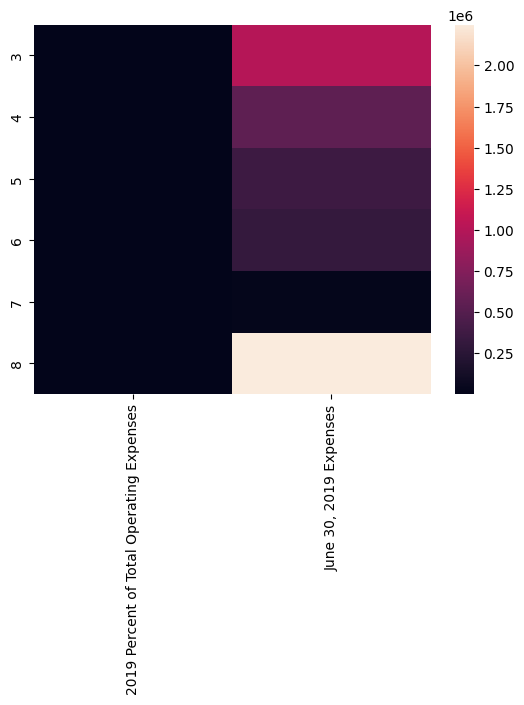

       June 30, 2019 Expenses  2019 Percent of Total Operating Expenses
count            6.000000e+00                                  6.000000
mean             7.493387e+05                                 33.333333
std              8.022760e+05                                 35.741666
min              2.442900e+04                                  1.000000
25%              3.220542e+05                                 14.500000
50%              4.569145e+05                                 20.000000
75%              8.887215e+05                                 39.750000
max              2.248016e+06                                100.000000


<Axes: >

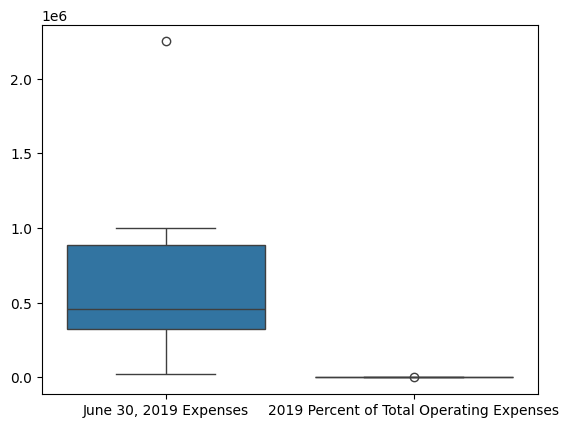

In [414]:
#strip white spaces, commas, and % characters from values in the dataframe
expenses19_df["2019 Percent of Total Operating Expenses"] = expenses19_df["2019 Percent of Total Operating Expenses"].str.strip().str.replace("%", "")
expenses19_df["June 30, 2019 Expenses"] = expenses19_df["June 30, 2019 Expenses"].str.strip().str.replace(",", "")
print(expenses19_df)

print(expenses19_df.dtypes) #print the data types of columns in dataframe
expenses19_df["Sources of Operating Expenses"] = expenses19_df["Sources of Operating Expenses"].astype(str)
expenses19_df["2019 Percent of Total Operating Expenses"] = expenses19_df["2019 Percent of Total Operating Expenses"].astype(int)
expenses19_df["June 30, 2019 Expenses"] = expenses19_df["June 30, 2019 Expenses"].astype(int)

print("After data type conversion", expenses19_df.dtypes)

#subset dataframe to create a heatmap to visualize missing data even though there were no missing data. Keep numeric value columns
expenses19_df_subset = expenses19_df[["2019 Percent of Total Operating Expenses", "June 30, 2019 Expenses"]]

#create heatmap of dataframe
sns.heatmap(expenses19_df_subset)
plt.show() #show heatmap

#find outliers in dataframe using describe()
print(expenses19_df.describe())

#create boxplot of dataframe without na to visualize outliers
sns.boxplot(data=expenses19_df)

In [415]:
#export cleaned 2019 expenses dataframe into csv file
expenses19_df.to_csv("../../data/processed-data/Budget2019_expenses.csv")

In [565]:
#keep both 2020 and 2019 for debts from the 2020 financial file
#extract table from pdf on page 11 using 'stream" because table data has no border: debt table
table20_19_debts = camelot.read_pdf(pdf_file20, flavor='stream', pages='11')

#if it is a table and table is found, then convert the table into a dataframe
if table20_19_debts:
    debts20_19_df = table20_19_debts[0].df
    print(debts20_19_df)
else:
    print("no tables found")

                                                   0  1          2          3
0  Bonds and notes outstanding for the fiscal yea...                         
1                                                             2020       2019
2                General Transportation System bonds  $    141,585    160,680
3                                      Revenue bonds     4,199,314  4,203,101
4                                        MBTPC bonds       304,585    304,585
5                                   Commercial paper        35,000     50,000
6                                              BAB’s       428,300    428,300
7                                                     $  5,108,784  5,146,666


In [566]:
#drop unneeded columns from the df dataframe
debts20_19_df = debts20_19_df.drop(1, axis=1)

#rename column headers in dataframe
debts20_19_df = debts20_19_df.rename(columns={0:"Sources of Debt", 2:"June 30, 2020 Debt", 3:"June 30, 2019 Debt"})

#drop rows indexs because they had blank values and other rows were correctly renamed
debts20_19_df = debts20_19_df.drop([0,1,2])
print(debts20_19_df)

    Sources of Debt June 30, 2020 Debt June 30, 2019 Debt
3     Revenue bonds          4,199,314          4,203,101
4       MBTPC bonds            304,585            304,585
5  Commercial paper             35,000             50,000
6             BAB’s            428,300            428,300
7                            5,108,784          5,146,666


In [567]:
#rename some values in the "Sources of Operating Revenue" column because the table was formatted with too much space for those cells
debts20_19_df.at[7,"Sources of Debt"] = "Total Debts"

    Sources of Debt June 30, 2020 Debt June 30, 2019 Debt
3     Revenue bonds            4199314            4203101
4       MBTPC bonds             304585             304585
5  Commercial paper              35000              50000
6             BAB’s             428300             428300
7       Total Debts            5108784            5146666
Sources of Debt       object
June 30, 2020 Debt    object
June 30, 2019 Debt    object
dtype: object
After data type conversion Sources of Debt       object
June 30, 2020 Debt     int64
June 30, 2019 Debt     int64
dtype: object


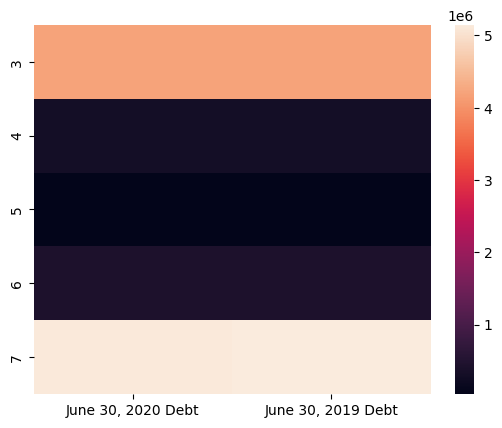

       June 30, 2020 Debt  June 30, 2019 Debt
count        5.000000e+00        5.000000e+00
mean         2.015197e+06        2.026530e+06
std          2.434454e+06        2.444321e+06
min          3.500000e+04        5.000000e+04
25%          3.045850e+05        3.045850e+05
50%          4.283000e+05        4.283000e+05
75%          4.199314e+06        4.203101e+06
max          5.108784e+06        5.146666e+06


<Axes: >

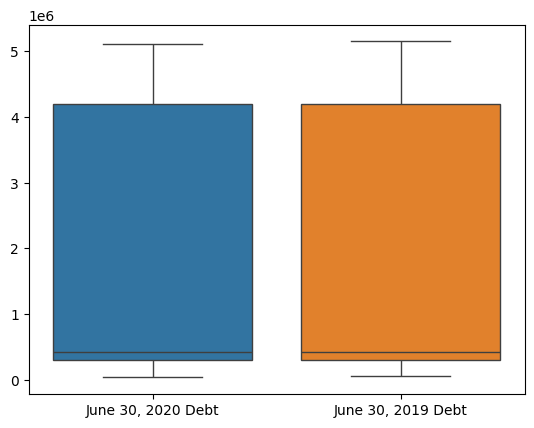

In [568]:
#strip white spaces and comma characters from values in the dataframe
debts20_19_df["June 30, 2020 Debt"] = debts20_19_df["June 30, 2020 Debt"].str.strip().str.replace(",", "")
debts20_19_df["June 30, 2019 Debt"] = debts20_19_df["June 30, 2019 Debt"].str.strip().str.replace(",", "")
print(debts20_19_df)

print(debts20_19_df.dtypes) #print the data types of columns in dataframe
debts20_19_df["Sources of Debt"] = debts20_19_df["Sources of Debt"].astype(str)
debts20_19_df["June 30, 2020 Debt"] = debts20_19_df["June 30, 2020 Debt"].astype(int)
debts20_19_df["June 30, 2019 Debt"] = debts20_19_df["June 30, 2019 Debt"].astype(int)

print("After data type conversion", debts20_19_df.dtypes)

#subset dataframe to create a heatmap to visualize missing data even though there were no missing data. Keep numeric value columns
debts20_19_df_subset = debts20_19_df[["June 30, 2020 Debt", "June 30, 2019 Debt"]]

#create heatmap of dataframe
sns.heatmap(debts20_19_df_subset)
plt.show() #show heatmap

#find outliers in dataframe using describe()
print(debts20_19_df.describe())

#create boxplot of dataframe without na to visualize outliers
sns.boxplot(data=debts20_19_df)

In [425]:
#export cleaned 2019 and 2020 debts dataframe into csv file
debts20_19_df.to_csv("../../data/processed-data/Budget2019_2020_debts.csv")

In [512]:
#join dataframes for net positions from 2023 to 2019
#join on common column "Statements of Revenue, Expenses and Changes in Net Position
net_join = pd.merge(df, combined_net21_df_index, on="Statements of Revenue, Expenses and Changes in Net Position")
#net_join = df.join(combined_net21_df_index, how='left')
#print(net_join) #check first join

net_join2 = pd.merge(net_join, net20_df, on="Statements of Revenue, Expenses and Changes in Net Position")
print(net_join2)

   Statements of Revenue, Expenses and Changes in Net Position  June 30, 2023  \
0                         Revenue from transportation                  376357   
1                            Total operating revenues                  452973   
2                             Transportation services                  822671   
3                            Other operating expenses                  968312   
4    Total operating expenses, excluding depreciation                 1790983   
5                       Depreciation and amortization                  562247   
6   Total operating expenses, including depreciati...                 2353230   
7                                      Operating loss                 1900257   
8                           Nonoperating revenue, net                 1812580   
9                    Capital grants and contributions                 1008130   
10                           Increase in net position                  920453   
11                    Beginn

In [513]:
#rename column headers to prepare for melt function
net_join2_rename = net_join2.rename(columns={"June 30, 2023":"2023-06-30", "June 30, 2022":"2022-06-30", "June 30, 2021":"2021-06-30", "June 30, 2020":"2020-06-30", "June 30, 2019 Net Positions":"2019-06-30"})


In [524]:
#melt the joined net position dataframe to join with the ride reliability dataset on date column
melt_net_positions = net_join2_rename.melt(id_vars=["Statements of Revenue, Expenses and Changes in Net Position"], var_name='Date', value_name="Net Position Amounts (USD)")
#print(melt_net_positions)


   Statements of Revenue, Expenses and Changes in Net Position        Date  \
0                         Revenue from transportation           2023-06-30   
1                            Total operating revenues           2023-06-30   
2                             Transportation services           2023-06-30   
3                            Other operating expenses           2023-06-30   
4    Total operating expenses, excluding depreciation           2023-06-30   
..                                                ...                  ...   
60                          Nonoperating revenue, net           2019-06-30   
61                   Capital grants and contributions           2019-06-30   
62                           Increase in net position           2019-06-30   
63                    Beginning of year, net position           2019-06-30   
64                          End of year, net position           2019-06-30   

    Net Position Amounts (USD)  
0                       376357

In [493]:
#load the clean ride reliability dataset to join with the net position dataset
reliability = pd.read_csv("../../data/processed-data/Clean_Ride_Reliability.csv")

#convert csv file into a dataframe
reliability_df = pd.DataFrame(reliability)

#print(reliability_df.head())

#drop unneeded columns from the df dataframe
reliability_df_drop = reliability_df.drop(["Unnamed: 0", "trip_date", "ObjectId"], axis=1)

print(reliability_df_drop.head())

   ontime_trip_count  trip_count        Date         Time
0               5479        5884  2014-07-01  04:00:00+00
1               5297        5612  2014-07-02  04:00:00+00
2               4959        5306  2014-07-03  04:00:00+00
3               1530        1558  2014-07-04  04:00:00+00
4               2420        2580  2014-07-05  04:00:00+00


In [522]:
#join the joined net position dataframe with the ride reliability dataframe on the "Date" column
#net_position_reliabiity_df = pd.merge(melt_net_positions, reliability_df_drop, left_on=None)
net_position_reliabiity_df = melt_net_positions.join(reliability_df_drop, how='inner') #dates and date

#net_position_reliabiity_df = pd.concat([melt_net_positions, reliability_df_drop]) #joined but just stacked

print(net_position_reliabiity_df)


   Statements of Revenue, Expenses and Changes in Net Position       Dates  \
0                         Revenue from transportation           2023-06-30   
1                            Total operating revenues           2023-06-30   
2                             Transportation services           2023-06-30   
3                            Other operating expenses           2023-06-30   
4    Total operating expenses, excluding depreciation           2023-06-30   
..                                                ...                  ...   
60                          Nonoperating revenue, net           2019-06-30   
61                   Capital grants and contributions           2019-06-30   
62                           Increase in net position           2019-06-30   
63                    Beginning of year, net position           2019-06-30   
64                          End of year, net position           2019-06-30   

    Net Position Amounts (USD)  ontime_trip_count  trip_count  

In [523]:
#export joined dataframe to csv as test file
net_position_reliabiity_df.to_csv("../../data/processed-data/Net_positions_reliability.csv")

In [527]:
#test attempt convert date to datetime in both datasets
#this attempt merged the two dataframes together correctly!
melt_net_positions["Date"] = pd.to_datetime(melt_net_positions["Date"])
reliability_df_drop["Date"] = pd.to_datetime(reliability_df_drop["Date"])

merged_net = pd.merge(melt_net_positions, reliability_df_drop, on="Date", how="inner")
print(merged_net)

   Statements of Revenue, Expenses and Changes in Net Position       Date  \
0                         Revenue from transportation          2023-06-30   
1                            Total operating revenues          2023-06-30   
2                             Transportation services          2023-06-30   
3                            Other operating expenses          2023-06-30   
4    Total operating expenses, excluding depreciation          2023-06-30   
..                                                ...                 ...   
60                          Nonoperating revenue, net          2019-06-30   
61                   Capital grants and contributions          2019-06-30   
62                           Increase in net position          2019-06-30   
63                    Beginning of year, net position          2019-06-30   
64                          End of year, net position          2019-06-30   

    Net Position Amounts (USD)  ontime_trip_count  trip_count         Time 

In [528]:
#export joined dataframe to csv as test file
merged_net.to_csv("../../data/processed-data/attempt2_Net_positions_reliability.csv")

In [531]:
from datetime import datetime
#convert date observation into binary to better statistical tests and visualizations
#alternative analysis: add a column to the dataframe for binary classification target
merged_net_binary = merged_net

print(merged_net_binary["Date"].dtype) #check if column is datatime type

#we want to observe all dates after 2022-06-30-01 as "1"'s and all dates before 2022-06-30 as "0"'s
#split the data pre and post 2022-01-01 because that was the year the MBTA infrastructure renovation program began. Since this dataset only has the 6/30/2022 date, we will use that data as the benchmark for binary analysis
date_to_string = "2022-06-30" #set variable to 2022-06-30 to find its numeric format
date_convert = datetime.strptime(date_to_string, "%Y-%m-%d") #convert string date to datetime format
print(type(date_convert)) #check if it is datetime format
num_date = int(date_convert.timestamp()) #convert datetime to an integer
#num_date_result = num_date//10**9
#print(num_date_result)
print(num_date) #print the numeric conversion of the 2022-01-01 date which equals 1641013200, easier for if else statement to transform dates into binary values

merged_net_binary["Pre and Post 2021"] = merged_net_binary["Date"].astype('int64')//10**9 #convert dates in the "weekly" column into numeric data type. Divide by 10**9 to convert the nanoseconds
print(merged_net_binary["Pre and Post 2021"].head()) #print first few rows of numeric format of dates in the "Pre and Post 2021" column

merged_net_binary["Pre and Post 2021 Binary"] = np.where(merged_net_binary["Pre and Post 2021"] > num_date, 1, 0) #if value in "Pre and Post 2021" column is greater than numeric value of 2022-01-01 = 1641013200, then value will be 1 if less than the date then value will be 0
print(merged_net_binary.head()) #print first few rows of binary dates


datetime64[ns]
<class 'datetime.datetime'>
1656561600
0    1688083200
1    1688083200
2    1688083200
3    1688083200
4    1688083200
Name: Pre and Post 2021, dtype: int64
  Statements of Revenue, Expenses and Changes in Net Position       Date  \
0                        Revenue from transportation          2023-06-30   
1                           Total operating revenues          2023-06-30   
2                            Transportation services          2023-06-30   
3                           Other operating expenses          2023-06-30   
4   Total operating expenses, excluding depreciation          2023-06-30   

   Net Position Amounts (USD)  ontime_trip_count  trip_count         Time  \
0                      376357               2925        3297  04:00:00+00   
1                      452973               2925        3297  04:00:00+00   
2                      822671               2925        3297  04:00:00+00   
3                      968312               2925        3297  0

In [532]:
#export joined dataframe to csv file
merged_net_binary.to_csv("../../data/processed-data/Net_positions_reliability_binary.csv")

In [534]:
#join dataframes for revenue
merged_revenue = pd.merge(revenue23_df,revenue21_df, on="Sources of Operating Revenue")
print(merged_revenue)

  Sources of Operating Revenue  June 30, 2023 Revenue  \
0                          Bus                  76549   
1                       Subway                 176521   
2                Commuter rail                 112801   
3              Other passenger                  10486   
4              Other operating                  76616   
5      Total Operating Revenue                 452973   

   2023 Percent of Total Operating Revenue  June 30, 2022 Revenue  \
0                                       17                  62305   
1                                       39                 172174   
2                                       25                  80784   
3                                        2                   7029   
4                                       17                  64565   
5                                      100                 386857   

   2022 Percent of Total Operating Revenue  June 30, 2021 Revenue  \
0                                       16     

In [537]:
#rename columns
merged_revenue_rename = merged_revenue.rename(columns={"June 30, 2023 Revenue":"2023-06-30", "June 30, 2022 Revenue":"2022-06-30", "June 30, 2021 Revenue":"2021-06-30", "June 30, 2020 Revenue":"2020-06-30"})

#drop the percent of total operating revenue columns to make melt function easier
merged_revenue_drop = merged_revenue_rename.drop(["2023 Percent of Total Operating Revenue", "2022 Percent of Total Operating Revenue", "2021 Percent of Total Operating Revenue", "2020 Percent of Total Operating Revenue"], axis=1)

#melt the joined revenue dataframe to join with the ride reliability dataset on date column
melt_revenue = merged_revenue_drop.melt(id_vars=["Sources of Operating Revenue"], var_name='Date', value_name="Revenue (USD)")
print(melt_revenue)

   Sources of Operating Revenue        Date  Revenue (USD)
0                           Bus  2023-06-30          76549
1                        Subway  2023-06-30         176521
2                 Commuter rail  2023-06-30         112801
3               Other passenger  2023-06-30          10486
4               Other operating  2023-06-30          76616
5       Total Operating Revenue  2023-06-30         452973
6                           Bus  2022-06-30          62305
7                        Subway  2022-06-30         172174
8                 Commuter rail  2022-06-30          80784
9               Other passenger  2022-06-30           7029
10              Other operating  2022-06-30          64565
11      Total Operating Revenue  2022-06-30         386857
12                          Bus  2021-06-30          36713
13                       Subway  2021-06-30          93635
14                Commuter rail  2021-06-30          33109
15              Other passenger  2021-06-30           36

In [538]:
melt_revenue["Date"] = pd.to_datetime(melt_revenue["Date"])
#reliability_df_drop["Date"] = pd.to_datetime(reliability_df_drop["Date"])

merged_rev_rel = pd.merge(melt_revenue, reliability_df_drop, on="Date", how="inner")
print(merged_rev_rel)

   Sources of Operating Revenue       Date  Revenue (USD)  ontime_trip_count  \
0                           Bus 2023-06-30          76549               2925   
1                        Subway 2023-06-30         176521               2925   
2                 Commuter rail 2023-06-30         112801               2925   
3               Other passenger 2023-06-30          10486               2925   
4               Other operating 2023-06-30          76616               2925   
5       Total Operating Revenue 2023-06-30         452973               2925   
6                           Bus 2022-06-30          62305               3104   
7                        Subway 2022-06-30         172174               3104   
8                 Commuter rail 2022-06-30          80784               3104   
9               Other passenger 2022-06-30           7029               3104   
10              Other operating 2022-06-30          64565               3104   
11      Total Operating Revenue 2022-06-

In [539]:
from datetime import datetime
#convert date observation into binary to better statistical tests and visualizations
#alternative analysis: add a column to the dataframe for binary classification target
merged_revenue_binary = merged_rev_rel

print(merged_revenue_binary["Date"].dtype) #check if column is datatime type

#we want to observe all dates after 2022-06-30-01 as "1"'s and all dates before 2022-06-30 as "0"'s
#split the data pre and post 2022-01-01 because that was the year the MBTA infrastructure renovation program began. Since this dataset only has the 6/30/2022 date, we will use that data as the benchmark for binary analysis
#date_to_string = "2022-06-30" #set variable to 2022-06-30 to find its numeric format
#date_convert = datetime.strptime(date_to_string, "%Y-%m-%d") #convert string date to datetime format
#print(type(date_convert)) #check if it is datetime format
#num_date = int(date_convert.timestamp()) #convert datetime to an integer
#num_date_result = num_date//10**9
#print(num_date_result)
#print(num_date) #print the numeric conversion of the 2022-06-30, easier for if else statement to transform dates into binary values

merged_revenue_binary["Pre and Post 2021"] = merged_revenue_binary["Date"].astype('int64')//10**9 #convert dates in the "weekly" column into numeric data type. Divide by 10**9 to convert the nanoseconds
print(merged_revenue_binary["Pre and Post 2021"].head()) #print first few rows of numeric format of dates in the "Pre and Post 2021" column

#num_date variable was set to 2022-06-30 from previous merge of dataframes
merged_revenue_binary["Pre and Post 2021 Binary"] = np.where(merged_revenue_binary["Pre and Post 2021"] > num_date, 1, 0) #if value in "Pre and Post 2021" column is greater than numeric value of 2022-01-01 = 1641013200, then value will be 1 if less than the date then value will be 0
print(merged_revenue_binary.head()) #print first few rows of binary dates

datetime64[ns]
0    1688083200
1    1688083200
2    1688083200
3    1688083200
4    1688083200
Name: Pre and Post 2021, dtype: int64
  Sources of Operating Revenue       Date  Revenue (USD)  ontime_trip_count  \
0                          Bus 2023-06-30          76549               2925   
1                       Subway 2023-06-30         176521               2925   
2                Commuter rail 2023-06-30         112801               2925   
3              Other passenger 2023-06-30          10486               2925   
4              Other operating 2023-06-30          76616               2925   

   trip_count         Time  Pre and Post 2021  Pre and Post 2021 Binary  
0        3297  04:00:00+00         1688083200                         1  
1        3297  04:00:00+00         1688083200                         1  
2        3297  04:00:00+00         1688083200                         1  
3        3297  04:00:00+00         1688083200                         1  
4        3297  04:00:0

In [540]:
#export joined dataframe to csv file
merged_revenue_binary.to_csv("../../data/processed-data/Revenue_reliability_binary.csv")

In [542]:
#merge all the dataframes for expenses
expenses_merged = pd.merge(expenses23_df, expenses21_df, on="Sources of Operating Expenses")
#print(expenses_merged)
expenses_merged2 = pd.merge(expenses_merged , expenses19_df, on="Sources of Operating Expenses")
print(expenses_merged2.head())

   Sources of Operating Expenses  June 30, 2023 Expenses  \
0             Wages and benefits                  822671   
1                  Commuter rail                  634244   
2  Depreciation and amortization                  562247   
3          Material and supplies                  304646   
4                Other operating                   29422   

   2023 Percent of Total Operating Expenses  June 30, 2022 Expenses  \
0                                        35                  858544   
1                                        27                  581500   
2                                        24                  526776   
3                                        13                  283548   
4                                         1                   25051   

   2022 Percent of Total Operating Expenses  June 30, 2021 Expenses  \
0                                        38                  838897   
1                                        26                  542226   

In [543]:
#rename columns
expenses_merged2_rename = expenses_merged2.rename(columns={"June 30, 2023 Expenses":"2023-06-30", "June 30, 2022 Expenses":"2022-06-30", "June 30, 2021 Expenses":"2021-06-30", "June 30, 2020 Expenses":"2020-06-30", "June 30, 2019 Expenses":"2019-06-30"})

#drop the percent of total operating expenses columns to make melt function easier
expenses_merged2_drop = expenses_merged2_rename.drop(["2023 Percent of Total Operating Expenses", "2022 Percent of Total Operating Expenses", "2021 Percent of Total Operating Expenses", "2020 Percent of Total Operating Expenses", "2019 Percent of Total Operating Expenses"], axis=1)

#melt the joined revenue dataframe to join with the ride reliability dataset on date column
melt_expenses = expenses_merged2_drop.melt(id_vars=["Sources of Operating Expenses"], var_name='Date', value_name="Expenses (USD)")
print(melt_expenses.head())

   Sources of Operating Expenses        Date  Expenses (USD)
0             Wages and benefits  2023-06-30          822671
1                  Commuter rail  2023-06-30          634244
2  Depreciation and amortization  2023-06-30          562247
3          Material and supplies  2023-06-30          304646
4                Other operating  2023-06-30           29422


In [545]:
melt_expenses["Date"] = pd.to_datetime(melt_expenses["Date"])
#reliability_df_drop["Date"] = pd.to_datetime(reliability_df_drop["Date"])

merged_expenses_rel = pd.merge(melt_expenses, reliability_df_drop, on="Date", how="inner")
print(merged_expenses_rel.head())

   Sources of Operating Expenses       Date  Expenses (USD)  \
0             Wages and benefits 2023-06-30          822671   
1                  Commuter rail 2023-06-30          634244   
2  Depreciation and amortization 2023-06-30          562247   
3          Material and supplies 2023-06-30          304646   
4                Other operating 2023-06-30           29422   

   ontime_trip_count  trip_count         Time  
0               2925        3297  04:00:00+00  
1               2925        3297  04:00:00+00  
2               2925        3297  04:00:00+00  
3               2925        3297  04:00:00+00  
4               2925        3297  04:00:00+00  


In [546]:
from datetime import datetime
#convert date observation into binary to better statistical tests and visualizations
#alternative analysis: add a column to the dataframe for binary classification target
merged_expenses_rel_binary = merged_expenses_rel

print(merged_expenses_rel_binary["Date"].dtype) #check if column is datatime type

merged_expenses_rel_binary["Pre and Post 2021"] = merged_expenses_rel_binary["Date"].astype('int64')//10**9 #convert dates in the "Date" column into numeric data type. Divide by 10**9 to convert the nanoseconds
print(merged_expenses_rel_binary["Pre and Post 2021"].head()) #print first few rows of numeric format of dates in the "Pre and Post 2021" column

#num_date variable was set to 2022-06-30 from previous merge of dataframes
merged_expenses_rel_binary["Pre and Post 2021 Binary"] = np.where(merged_expenses_rel_binary["Pre and Post 2021"] > num_date, 1, 0) #if value in "Pre and Post 2021" column is greater than numeric value of 2022-01-01 = 1641013200, then value will be 1 if less than the date then value will be 0
print(merged_expenses_rel_binary.head()) #print first few rows of binary dates

datetime64[ns]
0    1688083200
1    1688083200
2    1688083200
3    1688083200
4    1688083200
Name: Pre and Post 2021, dtype: int64
   Sources of Operating Expenses       Date  Expenses (USD)  \
0             Wages and benefits 2023-06-30          822671   
1                  Commuter rail 2023-06-30          634244   
2  Depreciation and amortization 2023-06-30          562247   
3          Material and supplies 2023-06-30          304646   
4                Other operating 2023-06-30           29422   

   ontime_trip_count  trip_count         Time  Pre and Post 2021  \
0               2925        3297  04:00:00+00         1688083200   
1               2925        3297  04:00:00+00         1688083200   
2               2925        3297  04:00:00+00         1688083200   
3               2925        3297  04:00:00+00         1688083200   
4               2925        3297  04:00:00+00         1688083200   

   Pre and Post 2021 Binary  
0                         1  
1                  

In [547]:
#export joined dataframe to csv file
merged_expenses_rel_binary.to_csv("../../data/processed-data/Expenses_reliability_binary.csv")

In [569]:
#merge all the dataframes for debts
debts_merged = pd.merge(debts23_df, debts21_df, on="Sources of Debt")
#print(debts_merged)
debts_merged2 = pd.merge(debts_merged , debts20_19_df, on="Sources of Debt")
print(debts_merged2.head())

    Sources of Debt  June 30, 2023 Debt  June 30, 2022 Debt  \
0  Commercial paper              125000               40000   

   June 30, 2021 Debts  June 30, 2020 Debt  June 30, 2019 Debt  
0               200000               35000               50000  


In [570]:
#rename columns
debts_merged2_rename = debts_merged2.rename(columns={"June 30, 2023 Debt":"2023-06-30", "June 30, 2022 Debt":"2022-06-30", "June 30, 2021 Debts":"2021-06-30", "June 30, 2020 Debt":"2020-06-30", "June 30, 2019 Debt":"2019-06-30"})

#melt the joined revenue dataframe to join with the ride reliability dataset on date column
melt_debts = debts_merged2_rename.melt(id_vars=["Sources of Debt"], var_name='Date', value_name="Debt (USD)")
print(melt_debts.head())

    Sources of Debt        Date  Debt (USD)
0  Commercial paper  2023-06-30      125000
1  Commercial paper  2022-06-30       40000
2  Commercial paper  2021-06-30      200000
3  Commercial paper  2020-06-30       35000
4  Commercial paper  2019-06-30       50000


In [571]:
melt_debts["Date"] = pd.to_datetime(melt_debts["Date"])
#reliability_df_drop["Date"] = pd.to_datetime(reliability_df_drop["Date"])

merged_debts_rel = pd.merge(melt_debts, reliability_df_drop, on="Date", how="inner")
print(merged_debts_rel.head())

    Sources of Debt       Date  Debt (USD)  ontime_trip_count  trip_count  \
0  Commercial paper 2023-06-30      125000               2925        3297   
1  Commercial paper 2022-06-30       40000               3104        3404   
2  Commercial paper 2021-06-30      200000               2329        2727   
3  Commercial paper 2020-06-30       35000               1825        1894   
4  Commercial paper 2019-06-30       50000               1914        1999   

          Time  
0  04:00:00+00  
1  04:00:00+00  
2  04:00:00+00  
3  04:00:00+00  
4  04:00:00+00  


In [572]:
from datetime import datetime
#convert date observation into binary to better statistical tests and visualizations
#alternative analysis: add a column to the dataframe for binary classification target
merged_debts_rel_binary = merged_debts_rel

print(merged_debts_rel_binary["Date"].dtype) #check if column is datatime type

merged_debts_rel_binary["Pre and Post 2021"] = merged_debts_rel_binary["Date"].astype('int64')//10**9 #convert dates in the "Date" column into numeric data type. Divide by 10**9 to convert the nanoseconds
print(merged_debts_rel_binary["Pre and Post 2021"].head()) #print first few rows of numeric format of dates in the "Pre and Post 2021" column

#num_date variable was set to 2022-06-30 from previous merge of dataframes
merged_debts_rel_binary["Pre and Post 2021 Binary"] = np.where(merged_debts_rel_binary["Pre and Post 2021"] > num_date, 1, 0) #if value in "Pre and Post 2021" column is greater than numeric value of 2022-01-01 = 1641013200, then value will be 1 if less than the date then value will be 0
print(merged_debts_rel_binary.head()) #print first few rows of binary dates

datetime64[ns]
0    1688083200
1    1656547200
2    1625011200
3    1593475200
4    1561852800
Name: Pre and Post 2021, dtype: int64
    Sources of Debt       Date  Debt (USD)  ontime_trip_count  trip_count  \
0  Commercial paper 2023-06-30      125000               2925        3297   
1  Commercial paper 2022-06-30       40000               3104        3404   
2  Commercial paper 2021-06-30      200000               2329        2727   
3  Commercial paper 2020-06-30       35000               1825        1894   
4  Commercial paper 2019-06-30       50000               1914        1999   

          Time  Pre and Post 2021  Pre and Post 2021 Binary  
0  04:00:00+00         1688083200                         1  
1  04:00:00+00         1656547200                         0  
2  04:00:00+00         1625011200                         0  
3  04:00:00+00         1593475200                         0  
4  04:00:00+00         1561852800                         0  


In [573]:
#export joined dataframe to csv file
merged_debts_rel_binary.to_csv("../../data/processed-data/Debts_reliability_binary.csv")

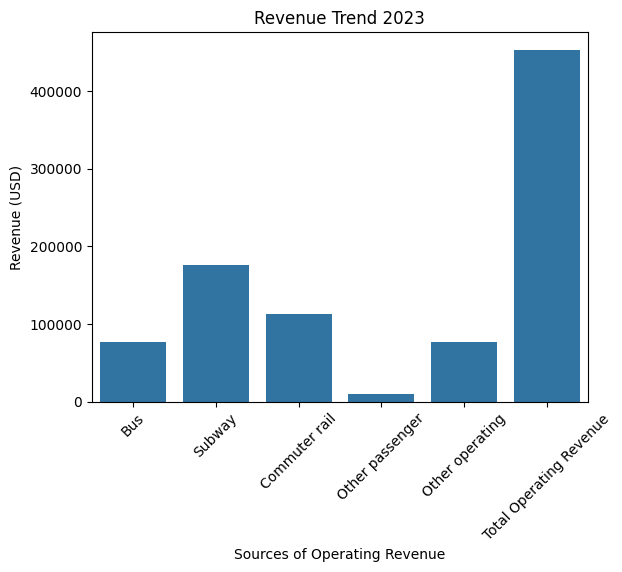

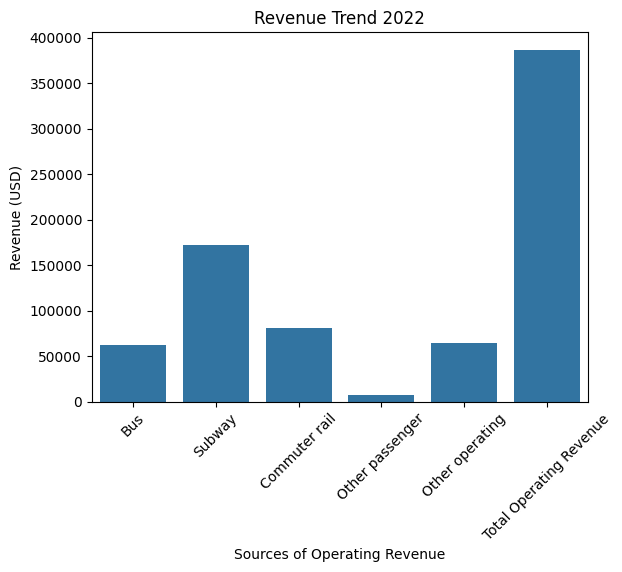

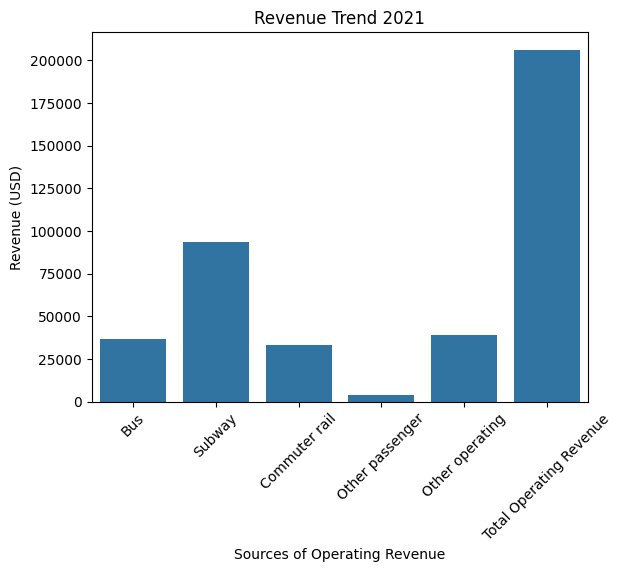

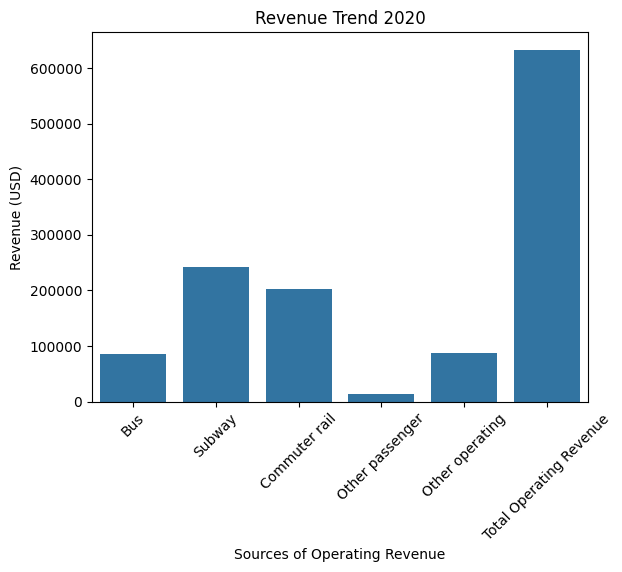

In [403]:
sns.barplot(data = revenue_join, y = "June 30, 2023 Revenue", x = "Sources of Operating Revenue")
plt.title("Revenue Trend 2023")
plt.xticks(rotation=45)
plt.ylabel("Revenue (USD)")
plt.show()

sns.barplot(data = revenue_join, y = "June 30, 2022 Revenue", x = "Sources of Operating Revenue")
plt.title("Revenue Trend 2022")
plt.xticks(rotation=45)
plt.ylabel("Revenue (USD)")
plt.show()


sns.barplot(data = revenue_join, y = "June 30, 2021 Revenue", x = "Sources of Operating Revenue")
plt.title("Revenue Trend 2021")
plt.xticks(rotation=45)
plt.ylabel("Revenue (USD)")
plt.show()

sns.barplot(data = revenue_join, y = "June 30, 2020 Revenue", x = "Sources of Operating Revenue")
plt.title("Revenue Trend 2020")
plt.xticks(rotation=45)
plt.ylabel("Revenue (USD)")
plt.show()

In [398]:
#join dataframes for expenses

#revenue_join1 = revenue23_df.join(revenue21_df, on="Sources of Operating Revenue")
expenses_join = pd.concat([expenses23_df, expenses21_df])
print(expenses_join)

   Sources of Operating Expenses  June 30, 2023 Expenses  \
3             Wages and benefits                822671.0   
4                  Commuter rail                634244.0   
5  Depreciation and amortization                562247.0   
6          Material and supplies                304646.0   
7                Other operating                 29422.0   
8       Total Operating Expenses               2353230.0   
3             Wages and benefits                     NaN   
4                  Commuter rail                     NaN   
5  Depreciation and amortization                     NaN   
6          Material and supplies                     NaN   
7                Other operating                     NaN   
8       Total Operating Expenses                     NaN   

   2023 Percent of Total Operating Expenses  June 30, 2022 Expenses  \
3                                      35.0                858544.0   
4                                      27.0                581500.0   
5     

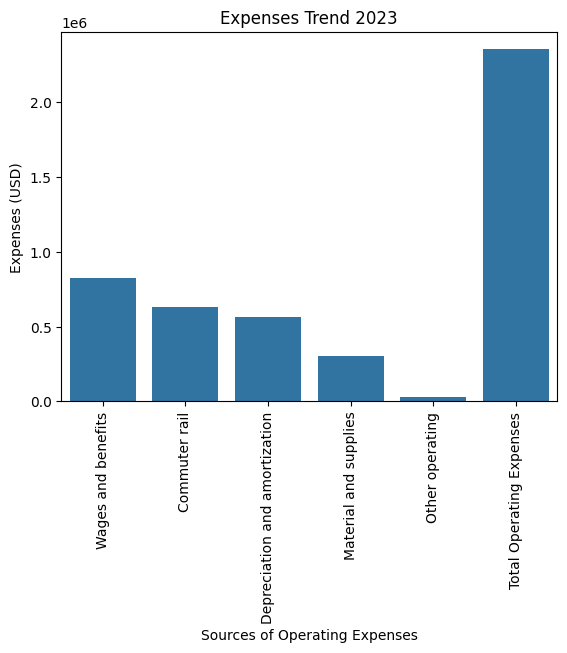

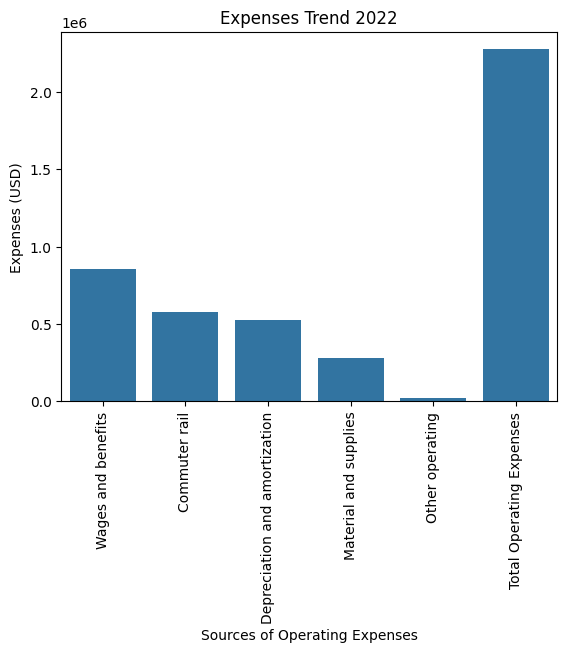

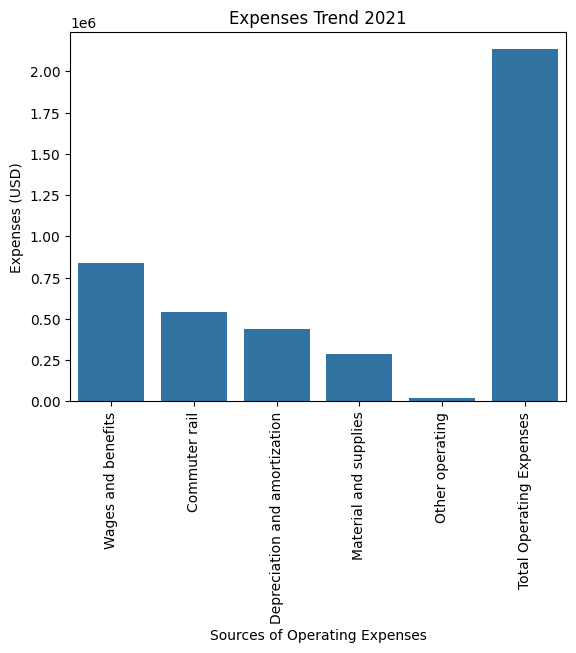

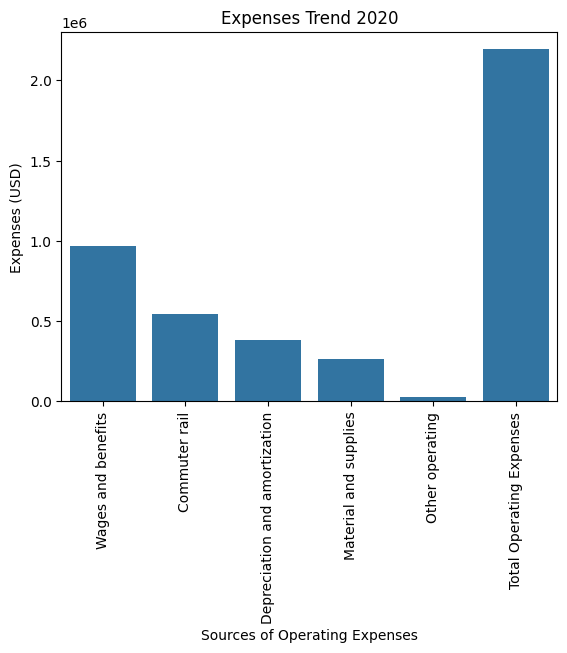

In [409]:
sns.barplot(data = expenses_join, y = "June 30, 2023 Expenses", x = "Sources of Operating Expenses")
plt.title("Expenses Trend 2023")
plt.xticks(rotation=90)
plt.ylabel("Expenses (USD)")
plt.show()

sns.barplot(data = expenses_join, y = "June 30, 2022 Expenses", x = "Sources of Operating Expenses")
plt.title("Expenses Trend 2022")
plt.xticks(rotation=90)
plt.ylabel("Expenses (USD)")
plt.show()


sns.barplot(data = expenses_join, y = "June 30, 2021 Expenses", x = "Sources of Operating Expenses")
plt.title("Expenses Trend 2021")
plt.xticks(rotation=90)
plt.ylabel("Expenses (USD)")
plt.show()

sns.barplot(data = expenses_join, y = "June 30, 2020 Expenses", x = "Sources of Operating Expenses")
plt.title("Expenses Trend 2020")
plt.xticks(rotation=90)
plt.ylabel("Expenses (USD)")
plt.show()

In [400]:
#join dataframes for debts

#revenue_join1 = revenue23_df.join(revenue21_df, on="Sources of Operating Revenue")
debts_join = pd.concat([debts23_df, debts21_df])
print(debts_join)

                       Sources of Debt  June 30, 2023 Debt  \
1                                                   2023.0   
2  General Transportation System bonds             99470.0   
3                   Revenue bonds, net           4248525.0   
4                                RRIFs            647545.0   
5                     Commercial paper            125000.0   
6                                 BABs            394300.0   
7                           Total Debt           5514840.0   
3  General Transportation System bonds                 NaN   
4                        Revenue bonds                 NaN   
5                               RRIF's                 NaN   
6                     Commercial paper                 NaN   
7                                BAB’s                 NaN   
8                          Total Debts                 NaN   

   June 30, 2022 Debt  June 30, 2021 Debts  
1              2022.0                  NaN  
2            110210.0                  Na

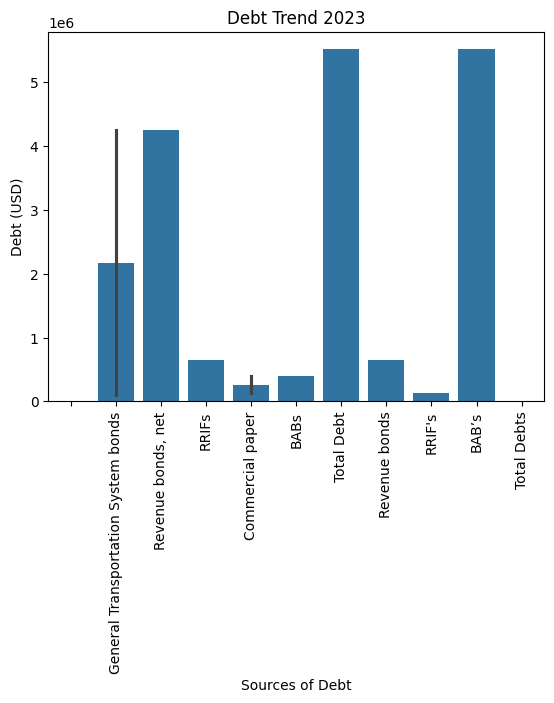

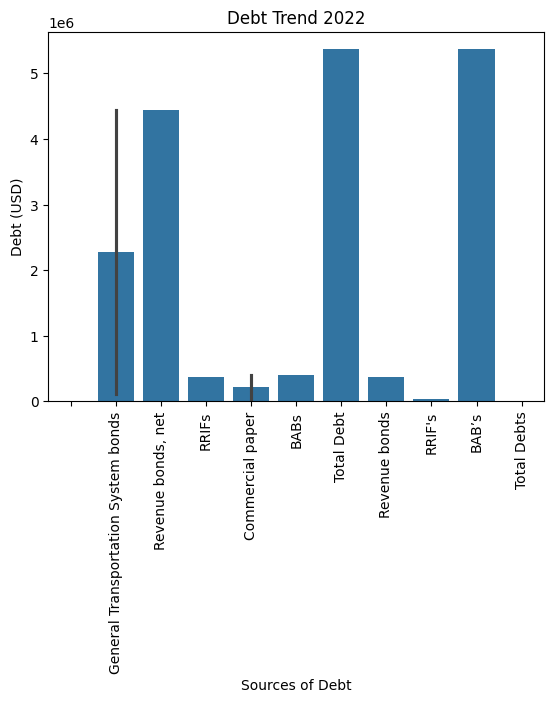

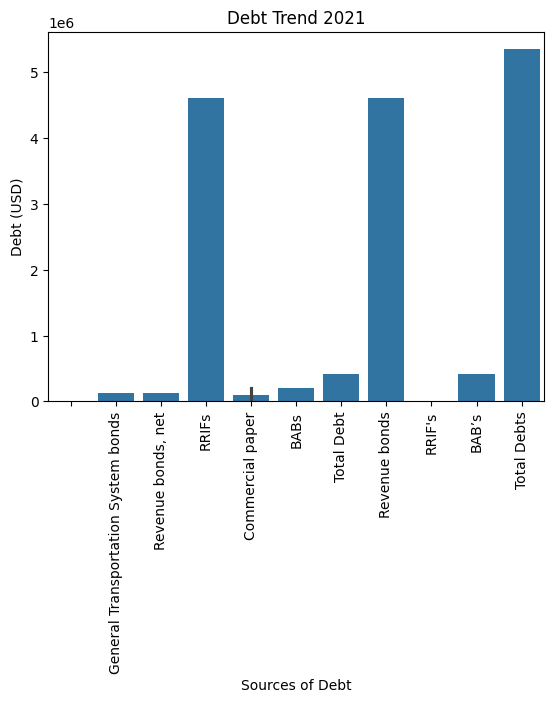

In [408]:
sns.barplot(data = debts_join, y = "June 30, 2023 Debt", x = "Sources of Debt")
plt.title("Debt Trend 2023")
plt.xticks(rotation=90)
plt.ylabel("Debt (USD)")
plt.show()

sns.barplot(data = debts_join, y = "June 30, 2022 Debt", x = "Sources of Debt")
plt.title("Debt Trend 2022")
plt.xticks(rotation=90)
plt.ylabel("Debt (USD)")
plt.show()


sns.barplot(data = debts_join, y = "June 30, 2021 Debts", x = "Sources of Debt")
plt.title("Debt Trend 2021")
plt.xticks(rotation=90)
plt.ylabel("Debt (USD)")
plt.show()

#sns.barplot(data = debts_join, y = "June 30, 2020 Expenses", x = "Sources of Debt")
#plt.title("Expenses Trend 2020")
#plt.xticks(rotation=45)
#plt.ylabel("Expenses (USD)")
#plt.show()